# 🔧 Day 25: GPU FinOps & Cost Optimization - Hands-on Lab

This notebook connects to a local Docker Compose cluster (via ngrok/cloudflared tunnel) to demonstrate:
1. **GPU Cluster Monitoring** - Real-time GPU metrics
2. **Cost Tracking (OpenCost-like)** - Per-node cost allocation & waste analysis
3. **Spot Instance Management** - Bidding, preemption, savings
4. **Autoscaling (KEDA-like)** - Policy-based GPU scaling
5. **Budget Management & Forecasting** - Alerts, burn rate

## Prerequisites
- Docker Compose running locally with the GPU FinOps Lab services
- Tunnel exposed via ngrok or cloudflared (free tier)

In [1]:
# Cell 1: Setup
!pip install -q requests pandas matplotlib plotly

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import json
from IPython.display import display, HTML, clear_output

In [2]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [3]:
# Cell 2: Configure Gateway URL
# Replace with your ngrok/cloudflared URL after running the tunnel
GATEWAY_URL = "https://patrol-lindsay-imperial-indicators.trycloudflare.com"  # <-- CHANGE THIS

# Test connection
try:
    r = requests.get(f"{GATEWAY_URL}/", timeout=10)
    print("✅ Connected to GPU FinOps Lab Gateway")
    print(json.dumps(r.json(), indent=2))
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("Make sure Docker Compose is running and tunnel is active")

✅ Connected to GPU FinOps Lab Gateway
{
  "service": "GPU FinOps Lab Gateway",
  "endpoints": {
    "cluster": "/cluster/*",
    "billing": "/billing/*",
    "spot": "/spot/*",
    "autoscaler": "/autoscaler/*",
    "cost": "/cost/*"
  }
}


---
## Part 1: GPU Cluster Monitoring
Observe the mock GPU cluster state — nodes, utilization, memory, power draw.

In [4]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [5]:
# Cell 3: View Cluster Nodes
nodes = requests.get(f"{GATEWAY_URL}/cluster/nodes").json()

print(f"📊 Cluster has {len(nodes)} nodes")
print("=" * 60)

for node_id, gpus in nodes.items():
    print(f"\n🖥️  {node_id}:")
    for gpu in gpus:
        status_icon = "🟢" if gpu['status'] == 'idle' else "🔴"
        print(f"   GPU {gpu['gpu_id']} [{gpu['gpu_type']}] {status_icon} "
              f"Util: {gpu['utilization']:.1f}% | "
              f"Mem: {gpu['memory_used_gb']:.1f}/{gpu['memory_total_gb']}GB | "
              f"Power: {gpu['power_draw_watts']:.0f}W | "
              f"Temp: {gpu['temperature_c']:.0f}°C")

📊 Cluster has 4 nodes

🖥️  node-00:
   GPU 0 [T4] 🟢 Util: 10.2% | Mem: 1.4/16.0GB | Power: 23W | Temp: 33°C
   GPU 1 [T4] 🟢 Util: 14.2% | Mem: 1.2/16.0GB | Power: 41W | Temp: 44°C

🖥️  node-01:
   GPU 0 [A100] 🟢 Util: 4.5% | Mem: 0.8/80.0GB | Power: 27W | Temp: 39°C
   GPU 1 [A100] 🟢 Util: 8.2% | Mem: 1.0/80.0GB | Power: 40W | Temp: 33°C

🖥️  node-02:
   GPU 0 [V100] 🟢 Util: 13.9% | Mem: 0.9/32.0GB | Power: 33W | Temp: 30°C
   GPU 1 [V100] 🟢 Util: 5.6% | Mem: 1.3/32.0GB | Power: 24W | Temp: 35°C

🖥️  node-03:
   GPU 0 [T4] 🟢 Util: 7.6% | Mem: 1.9/16.0GB | Power: 33W | Temp: 34°C
   GPU 1 [T4] 🟢 Util: 8.0% | Mem: 0.8/16.0GB | Power: 47W | Temp: 42°C


In [6]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [7]:
# Cell 4: Cluster Metrics Summary
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()

print("📈 Cluster Metrics")
print("=" * 40)
print(f"Total GPUs:          {metrics['total_gpus']}")
print(f"Busy GPUs:           {metrics['busy_gpus']}")
print(f"Idle GPUs:           {metrics['idle_gpus']}")
print(f"Avg Utilization:     {metrics['avg_utilization']:.1f}%")
print(f"Memory Used:         {metrics['total_memory_used_gb']:.1f} GB")
print(f"Memory Capacity:     {metrics['total_memory_capacity_gb']:.1f} GB")
print(f"Total Power Draw:    {metrics['total_power_draw_watts']:.0f} W")
print(f"Node Count:          {metrics['node_count']}")

📈 Cluster Metrics
Total GPUs:          8
Busy GPUs:           0
Idle GPUs:           8
Avg Utilization:     9.0%
Memory Used:         9.4 GB
Memory Capacity:     288.0 GB
Total Power Draw:    268 W
Node Count:          4


---
## Part 2: Workload Submission & Cost Tracking
Submit GPU workloads and track their costs in real-time.

In [8]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [9]:
# Cell 5: Submit multiple workloads
workloads = [
    {"workload_id": "train-resnet-001", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 300},
    {"workload_id": "train-bert-002", "gpu_type_preferred": "A100", "gpu_count": 1, "duration_seconds": 600},
    {"workload_id": "inference-api-003", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 120},
    {"workload_id": "train-llm-004", "gpu_type_preferred": "A100", "gpu_count": 2, "duration_seconds": 900},
]

print("🚀 Submitting workloads...")
for wl in workloads:
    r = requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json=wl)
    result = r.json()
    print(f"   {wl['workload_id']}: {result['status']} → {result.get('assigned', 'queued')}")

# Check cluster state after submission
print("\n📊 Updated metrics:")
metrics = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   Busy GPUs: {metrics['busy_gpus']}/{metrics['total_gpus']} | Utilization: {metrics['avg_utilization']:.1f}%")

🚀 Submitting workloads...
   train-resnet-001: running → [{'node_id': 'node-00', 'gpu_id': 0}]
   train-bert-002: running → [{'node_id': 'node-01', 'gpu_id': 0}]
   inference-api-003: running → [{'node_id': 'node-00', 'gpu_id': 1}]
   train-llm-004: running → [{'node_id': 'node-01', 'gpu_id': 1}, {'node_id': 'node-02', 'gpu_id': 0}]

📊 Updated metrics:
   Busy GPUs: 5/8 | Utilization: 51.7%


In [10]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [11]:
# Cell 6: Record billing for workloads
billing_events = [
    {"workload_id": "train-resnet-001", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 300, "is_spot": False},
    {"workload_id": "train-bert-002", "gpu_type": "A100", "gpu_count": 1, "duration_seconds": 600, "is_spot": False},
    {"workload_id": "inference-api-003", "gpu_type": "T4", "gpu_count": 1, "duration_seconds": 120, "is_spot": True},
    {"workload_id": "train-llm-004", "gpu_type": "A100", "gpu_count": 2, "duration_seconds": 900, "is_spot": True},
]

print("💰 Recording billing events...")
for event in billing_events:
    r = requests.post(f"{GATEWAY_URL}/billing/record", json=event)
    result = r.json()
    spot_label = "[SPOT]" if event['is_spot'] else "[ON-DEMAND]"
    print(f"   {event['workload_id']} {spot_label}: ${result['total_cost_usd']:.4f} "
          f"(saved ${result['savings_usd']:.4f})")

# Get billing summary
print("\n📋 Billing Summary:")
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total Cost:     ${summary['total_cost_usd']:.4f}")
print(f"   Total Savings:  ${summary['total_savings_usd']:.4f}")
print(f"   Budget Used:    {summary['budget_utilization_pct']:.1f}%")
print(f"   Alert Status:   {summary['alert']}")

💰 Recording billing events...
   train-resnet-001 [ON-DEMAND]: $0.0292 (saved $0.0000)
   train-bert-002 [ON-DEMAND]: $0.6117 (saved $0.0000)
   inference-api-003 [SPOT]: $0.0035 (saved $0.0082)
   train-llm-004 [SPOT]: $0.5505 (saved $1.2845)

📋 Billing Summary:
   Total Cost:     $1.1949
   Total Savings:  $1.2927
   Budget Used:    1.2%
   Alert Status:   OK


---
## Part 3: Spot Instance Management
Demonstrate spot bidding, preemption handling, and cost savings.

In [12]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [13]:
# Cell 7: Check spot pricing
spot_pricing = requests.get(f"{GATEWAY_URL}/spot/pricing").json()

print("💹 Current Spot Pricing")
print("=" * 60)
print(f"{'GPU Type':<10} {'On-Demand':<12} {'Spot Price':<12} {'Discount':<10} {'Availability'}")
print("-" * 60)
for gpu, info in spot_pricing.items():
    print(f"{gpu:<10} ${info['on_demand_price']:<10.2f} ${info['current_spot_price']:<10.4f} "
          f"{info['discount_pct']:<8.1f}% {info['availability']}")

💹 Current Spot Pricing
GPU Type   On-Demand    Spot Price   Discount   Availability
------------------------------------------------------------
T4         $0.35       $0.2649     24.3    % high
A100       $3.67       $2.1949     40.2    % medium
V100       $2.48       $1.6625     33.0    % high


In [14]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [15]:
# Cell 8: Request spot instances
spot_requests = [
    {"instance_id": "spot-t4-001", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": "batch-job-1"},
    {"instance_id": "spot-t4-002", "gpu_type": "T4", "gpu_count": 1, "max_price_per_hour": 0.12, "workload_id": "batch-job-2"},
    {"instance_id": "spot-a100-001", "gpu_type": "A100", "gpu_count": 1, "max_price_per_hour": 1.50, "workload_id": "training-3"},
]

print("🎯 Requesting Spot Instances...")
for req in spot_requests:
    r = requests.post(f"{GATEWAY_URL}/spot/request", json=req)
    result = r.json()
    status_icon = "✅" if result['status'] == 'granted' else "❌"
    print(f"   {status_icon} {req['instance_id']} ({req['gpu_type']}): {result['status']}")
    if result['status'] == 'rejected':
        print(f"      Reason: {result.get('reason', 'N/A')}")

🎯 Requesting Spot Instances...
   ✅ spot-t4-001 (T4): granted
   ✅ spot-t4-002 (T4): granted
   ✅ spot-a100-001 (A100): granted


In [16]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [17]:
# Cell 9: Simulate spot preemption
print("⚡ Simulating spot preemption event...")
preemption = requests.post(f"{GATEWAY_URL}/spot/simulate-preemption").json()

print(f"\n   Preempted instances: {preemption['preempted_count']}")
print(f"   Still active: {preemption['total_active']}")

if preemption['preempted_instances']:
    print("\n   ⚠️  Preempted:")
    for p in preemption['preempted_instances']:
        print(f"      - {p['instance_id']} (ran for {p['runtime_seconds']:.0f}s, "
              f"{p['notice_seconds']}s warning)")

# Savings report
print("\n💰 Spot Savings Report:")
savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot cost:        ${savings['total_spot_cost']:.4f}")
print(f"   On-demand equiv:  ${savings['on_demand_equivalent']:.4f}")
print(f"   Total saved:      ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

⚡ Simulating spot preemption event...

   Preempted instances: 0
   Still active: 3

💰 Spot Savings Report:
   Spot cost:        $0.0003
   On-demand equiv:  $0.0009
   Total saved:      $0.0006 (62.2%)


---
## Part 4: Autoscaling (KEDA-like)
Configure and trigger GPU autoscaling based on utilization thresholds.

In [18]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [19]:
# Cell 10: View and update autoscaling policy
policy = requests.get(f"{GATEWAY_URL}/autoscaler/policy").json()
print("📜 Current Autoscaling Policy:")
for k, v in policy.items():
    print(f"   {k}: {v}")

# Update policy - more aggressive scaling
new_policy = {
    "scale_up_threshold": 70,
    "scale_down_threshold": 25,
    "cooldown_seconds": 30,
    "max_nodes": 10,
    "min_nodes": 2,
    "preferred_gpu_type": "T4",
    "cost_aware": True
}

print("\n🔄 Updating policy...")
updated = requests.post(f"{GATEWAY_URL}/autoscaler/policy", json=new_policy).json()
print("   ✅ Policy updated")

📜 Current Autoscaling Policy:
   scale_up_threshold: 80.0
   scale_down_threshold: 20.0
   cooldown_seconds: 60
   max_nodes: 8
   min_nodes: 1
   preferred_gpu_type: T4
   cost_aware: True

🔄 Updating policy...
   ✅ Policy updated


In [20]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [21]:
# Cell 11: Trigger autoscaler evaluation
print("🔄 Evaluating autoscaling decision...")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()

action_icons = {"scale_up": "⬆️", "scale_down": "⬇️", "no_action": "➡️"}
print(f"\n   {action_icons.get(decision['action'], '❓')} Action: {decision['action'].upper()}")
print(f"   Reason: {decision['reason']}")
print(f"   Current utilization: {decision['current_utilization']:.1f}%")
print(f"   Nodes: {decision['node_count']} → {decision['target_node_count']}")

# Run multiple evaluations to show scaling behavior
print("\n📊 Running 5 evaluation cycles...")
for i in range(5):
    time.sleep(2)
    d = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
    print(f"   Cycle {i+1}: {d['action']:<12} | Util: {d['current_utilization']:.1f}% | Nodes: {d['node_count']}→{d['target_node_count']}")

🔄 Evaluating autoscaling decision...

   ➡️ Action: NO_ACTION
   Reason: Utilization 51.7% within thresholds [25.0-70.0%]
   Current utilization: 51.7%
   Nodes: 4 → 4

📊 Running 5 evaluation cycles...
   Cycle 1: no_action    | Util: 51.7% | Nodes: 4→4
   Cycle 2: no_action    | Util: 51.7% | Nodes: 4→4
   Cycle 3: no_action    | Util: 51.7% | Nodes: 4→4
   Cycle 4: no_action    | Util: 51.7% | Nodes: 4→4
   Cycle 5: no_action    | Util: 51.7% | Nodes: 4→4


---
## Part 5: Cost Analysis & Optimization (OpenCost-like)
Analyze cost allocation, identify waste, and get recommendations.

In [22]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [23]:
# Cell 12: Take cost snapshots
print("📸 Taking cost snapshots...")
snapshots = []
for i in range(5):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    snapshots.append(snap)
    print(f"   Snapshot {i+1}: Total=${snap['total_cost_usd']:.6f} | "
          f"Idle=${snap['total_idle_cost_usd']:.6f} | "
          f"Waste={snap['waste_pct']:.1f}%")
    time.sleep(1)

📸 Taking cost snapshots...
   Snapshot 1: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 2: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 3: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 4: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%
   Snapshot 5: Total=$0.038056 | Idle=$0.008833 | Waste=23.2%


In [24]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [25]:
# Cell 13: Waste Report
waste = requests.get(f"{GATEWAY_URL}/cost/waste-report").json()

print("🗑️  WASTE ANALYSIS REPORT")
print("=" * 50)
print(f"   Average Waste:          {waste.get('avg_waste_pct', 0):.1f}%")
print(f"   Total Idle Cost:        ${waste.get('total_idle_cost_usd', 0):.6f}")
print(f"   Total Cost:             ${waste.get('total_cost_usd', 0):.6f}")
print(f"   Potential Monthly Save:  ${waste.get('potential_monthly_savings', 0):.2f}")
print(f"   Severity:               {waste.get('severity', 'N/A')}")

🗑️  WASTE ANALYSIS REPORT
   Average Waste:          23.2%
   Total Idle Cost:        $0.044165
   Total Cost:             $0.190280
   Potential Monthly Save:  $2289.51
   Severity:               LOW


In [26]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [27]:
# Cell 14: Get Optimization Recommendations
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()

print("💡 COST OPTIMIZATION RECOMMENDATIONS")
print("=" * 60)
for i, rec in enumerate(recs, 1):
    priority_icons = {"HIGH": "🔴", "MEDIUM": "🟡", "LOW": "🟢"}
    icon = priority_icons.get(rec['priority'], '⚪')
    print(f"\n{i}. {icon} [{rec['priority']}] {rec['type']}")
    print(f"   {rec['description']}")
    print(f"   Estimated savings: {rec['estimated_savings_pct']:.1f}%")

💡 COST OPTIMIZATION RECOMMENDATIONS

1. 🟡 [MEDIUM] USE_SPOT
   Switch fault-tolerant workloads to spot instances for 60-70% savings.
   Estimated savings: 65.0%

2. 🟢 [LOW] SCHEDULING
   Schedule non-urgent training jobs during off-peak hours for lower spot prices.
   Estimated savings: 20.0%


In [28]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [29]:
# Cell 15: Full Dashboard View
dashboard = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()

print("📊 GPU FinOps DASHBOARD")
print("=" * 60)

cm = dashboard.get('cluster_metrics', {})
print(f"\n🖥️  CLUSTER: {cm.get('total_gpus', 0)} GPUs across {cm.get('node_count', 0)} nodes")
print(f"   Utilization: {cm.get('avg_utilization', 0):.1f}% | Busy: {cm.get('busy_gpus', 0)} | Idle: {cm.get('idle_gpus', 0)}")

bs = dashboard.get('billing_summary', {})
print(f"\n💰 BILLING: ${bs.get('total_cost_usd', 0):.4f} / ${bs.get('budget_usd', 0):.2f} budget")
print(f"   Alert: {bs.get('alert', 'N/A')} | Savings: ${bs.get('total_savings_usd', 0):.4f}")

ss = dashboard.get('spot_savings', {})
print(f"\n🎯 SPOT: Saved ${ss.get('total_savings', 0):.4f} ({ss.get('savings_pct', 0):.1f}%)")

wa = dashboard.get('waste_analysis', {})
if wa:
    print(f"\n🗑️  WASTE: {wa.get('avg_waste_pct', 0):.1f}% | Severity: {wa.get('severity', 'N/A')}")

📊 GPU FinOps DASHBOARD

🖥️  CLUSTER: 8 GPUs across 4 nodes
   Utilization: 51.7% | Busy: 5 | Idle: 3

💰 BILLING: $1.1949 / $100.00 budget
   Alert: OK | Savings: $1.2927

🎯 SPOT: Saved $0.0187 (70.0%)

🗑️  WASTE: 23.2% | Severity: LOW


---
## Part 6: Visualization
Create charts for cost breakdown and utilization trends.

In [30]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


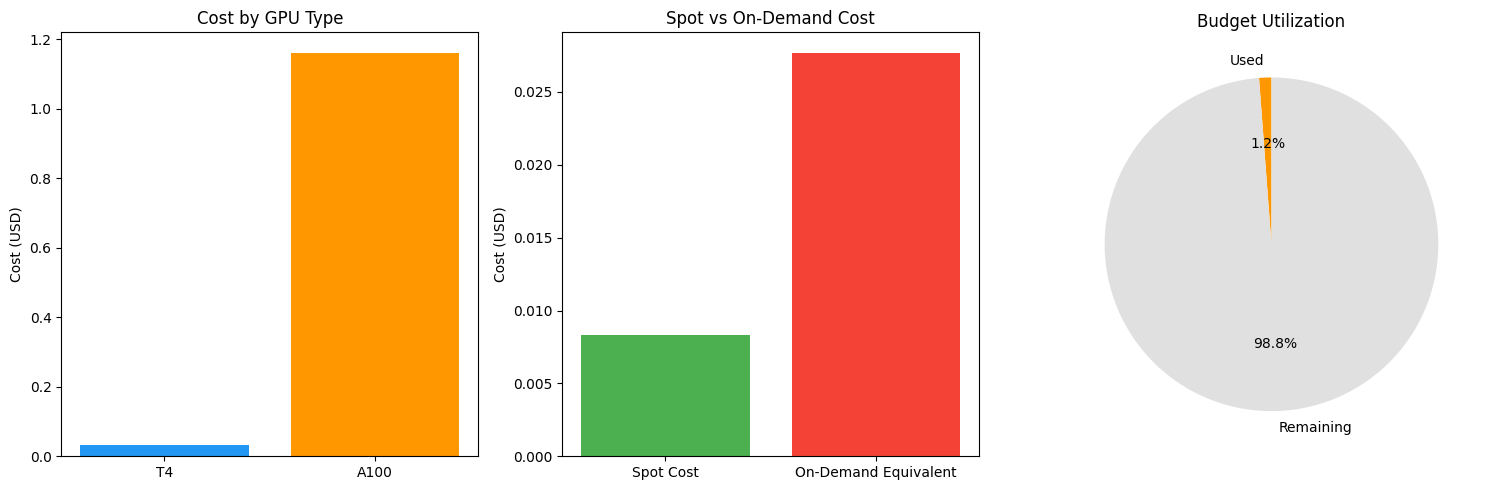

📊 Chart saved as finops_cost_breakdown.png


In [31]:
# Cell 16: Cost Breakdown Visualization
summary = requests.get(f"{GATEWAY_URL}/billing/summary").json()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chart 1: Cost by GPU type
cost_by_type = summary.get('cost_by_gpu_type', {})
if cost_by_type:
    types = list(cost_by_type.keys())
    costs = [cost_by_type[t]['cost'] for t in types]
    axes[0].bar(types, costs, color=['#2196F3', '#FF9800', '#4CAF50'])
    axes[0].set_title('Cost by GPU Type')
    axes[0].set_ylabel('Cost (USD)')

# Chart 2: Spot vs On-Demand
spot_data = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
labels = ['Spot Cost', 'On-Demand Equivalent']
values = [spot_data.get('total_spot_cost', 0), spot_data.get('on_demand_equivalent', 0)]
axes[1].bar(labels, values, color=['#4CAF50', '#F44336'])
axes[1].set_title('Spot vs On-Demand Cost')
axes[1].set_ylabel('Cost (USD)')

# Chart 3: Budget utilization
budget_used = summary.get('budget_utilization_pct', 0)
axes[2].pie([budget_used, 100-budget_used], labels=['Used', 'Remaining'],
            colors=['#FF9800', '#E0E0E0'], autopct='%1.1f%%', startangle=90)
axes[2].set_title('Budget Utilization')

plt.tight_layout()
plt.savefig('finops_cost_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved as finops_cost_breakdown.png")

In [32]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


📈 Collecting time-series data (10 snapshots)...


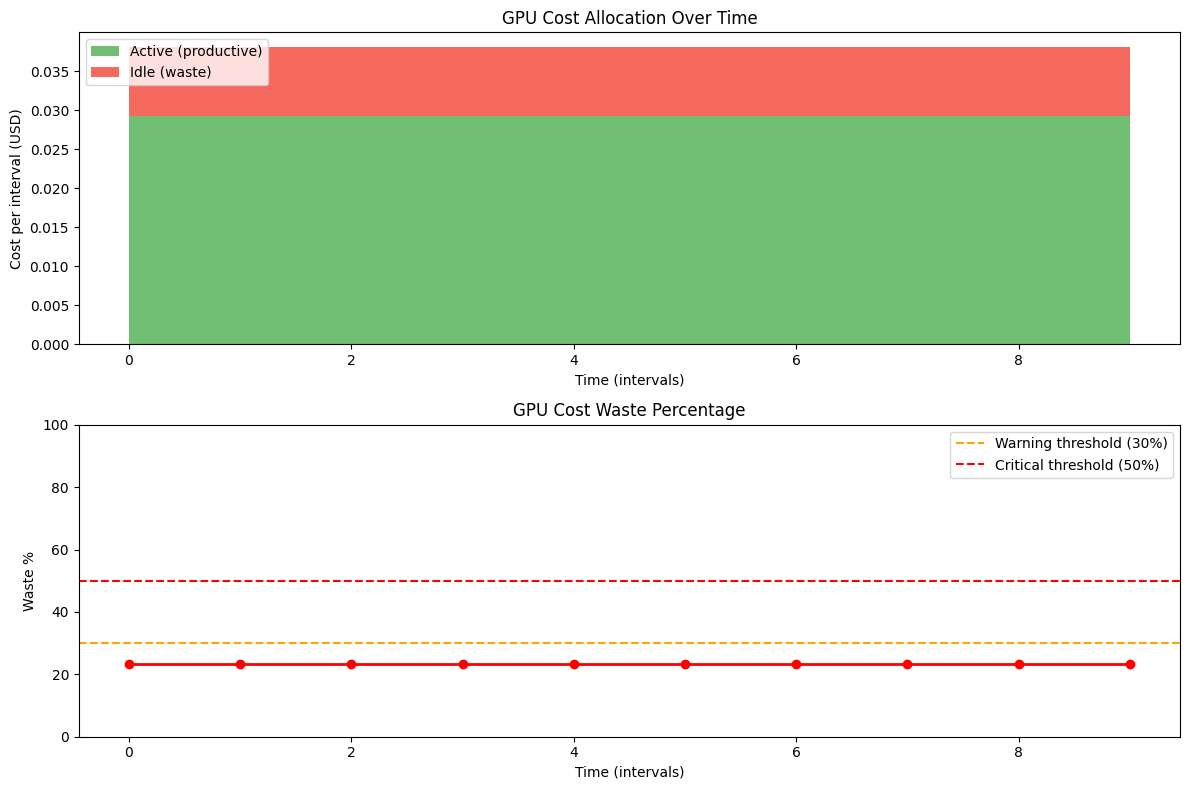

In [33]:
# Cell 17: Time-series cost tracking
print("📈 Collecting time-series data (10 snapshots)...")
ts_data = []
for i in range(10):
    snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
    ts_data.append({
        'time': i,
        'total_cost': snap['total_cost_usd'],
        'idle_cost': snap['total_idle_cost_usd'],
        'active_cost': snap['total_active_cost_usd'],
        'waste_pct': snap['waste_pct'],
    })
    time.sleep(1)

df = pd.DataFrame(ts_data)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Cost over time
ax1.stackplot(df['time'], df['active_cost'], df['idle_cost'],
              labels=['Active (productive)', 'Idle (waste)'],
              colors=['#4CAF50', '#F44336'], alpha=0.8)
ax1.set_xlabel('Time (intervals)')
ax1.set_ylabel('Cost per interval (USD)')
ax1.set_title('GPU Cost Allocation Over Time')
ax1.legend(loc='upper left')

# Waste percentage
ax2.plot(df['time'], df['waste_pct'], 'r-o', linewidth=2)
ax2.axhline(y=30, color='orange', linestyle='--', label='Warning threshold (30%)')
ax2.axhline(y=50, color='red', linestyle='--', label='Critical threshold (50%)')
ax2.set_xlabel('Time (intervals)')
ax2.set_ylabel('Waste %')
ax2.set_title('GPU Cost Waste Percentage')
ax2.legend()
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('finops_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7: Complete FinOps Workflow
Run a full cycle: submit workloads → monitor → detect waste → autoscale → optimize cost.

In [34]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [35]:
# Cell 18: Full FinOps Optimization Workflow
print("🔄 FULL FINOPS OPTIMIZATION WORKFLOW")
print("=" * 60)

# Step 1: Check initial state
print("\n1️⃣  Initial cluster state:")
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   GPUs: {m['total_gpus']} | Util: {m['avg_utilization']:.1f}% | Idle: {m['idle_gpus']}")

# Step 2: Submit heavy workloads to increase utilization
print("\n2️⃣  Submitting heavy workloads...")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type_preferred": "T4", "gpu_count": 1, "duration_seconds": 600
    })
m = requests.get(f"{GATEWAY_URL}/cluster/metrics").json()
print(f"   After load: Util: {m['avg_utilization']:.1f}% | Busy: {m['busy_gpus']}/{m['total_gpus']}")

# Step 3: Autoscaler evaluates
print("\n3️⃣  Autoscaler evaluation:")
decision = requests.post(f"{GATEWAY_URL}/autoscaler/evaluate").json()
print(f"   Decision: {decision['action']} - {decision['reason']}")

# Step 4: Cost snapshot
print("\n4️⃣  Cost analysis:")
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"   Total cost/interval: ${snap['total_cost_usd']:.6f}")
print(f"   Waste: {snap['waste_pct']:.1f}%")

# Step 5: Get recommendations
print("\n5️⃣  Recommendations:")
recs = requests.post(f"{GATEWAY_URL}/cost/recommendations").json()
for rec in recs:
    print(f"   [{rec['priority']}] {rec['type']}: savings ~{rec['estimated_savings_pct']}%")

# Step 6: Apply optimization - use spot for some workloads
print("\n6️⃣  Applying optimization: Switch to spot instances...")
for i in range(3):
    requests.post(f"{GATEWAY_URL}/spot/request", json={
        "instance_id": f"opt-spot-{i}", "gpu_type": "T4",
        "gpu_count": 1, "max_price_per_hour": 0.15, "workload_id": f"heavy-{i:03d}"
    })

savings = requests.get(f"{GATEWAY_URL}/spot/savings-report").json()
print(f"   Spot savings: ${savings['total_savings']:.4f} ({savings['savings_pct']:.1f}%)")

# Step 7: Complete workloads and record billing
print("\n7️⃣  Final billing:")
for i in range(5):
    requests.post(f"{GATEWAY_URL}/cluster/workloads/heavy-{i:03d}/complete")
    requests.post(f"{GATEWAY_URL}/billing/record", json={
        "workload_id": f"heavy-{i:03d}", "gpu_type": "T4",
        "gpu_count": 1, "duration_seconds": 600, "is_spot": i < 3
    })

final = requests.get(f"{GATEWAY_URL}/billing/summary").json()
print(f"   Total spend: ${final['total_cost_usd']:.4f}")
print(f"   Total saved: ${final['total_savings_usd']:.4f}")
print(f"   Budget: {final['budget_utilization_pct']:.1f}% used")
print(f"\n✅ Workflow complete!")

🔄 FULL FINOPS OPTIMIZATION WORKFLOW

1️⃣  Initial cluster state:
   GPUs: 8 | Util: 51.7% | Idle: 3

2️⃣  Submitting heavy workloads...
   After load: Util: 74.7% | Busy: 8/8

3️⃣  Autoscaler evaluation:
   Decision: scale_up - Utilization 74.7% > threshold 70.0%

4️⃣  Cost analysis:
   Total cost/interval: $0.040000
   Waste: 4.9%

5️⃣  Recommendations:
   [MEDIUM] USE_SPOT: savings ~65.0%
   [LOW] SCHEDULING: savings ~20.0%

6️⃣  Applying optimization: Switch to spot instances...
   Spot savings: $0.0371 (70.0%)

7️⃣  Final billing:
   Total spend: $1.3640
   Total saved: $1.4151
   Budget: 1.4% used

✅ Workflow complete!


---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** to measure time & cost savings
4. Reports all costs back to the FinOps gateway

In [36]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [37]:
# Cell 19: Install dependencies & detect real GPU
!pip install -q torch torchvision pynvml

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import subprocess
import threading

try:
    from pynvml import (nvmlInit, nvmlDeviceGetHandleByIndex,
                        nvmlDeviceGetUtilizationRates, nvmlDeviceGetMemoryInfo,
                        nvmlDeviceGetPowerUsage, nvmlDeviceGetTemperature)
    PYNVML_AVAILABLE = True
except ImportError:
    PYNVML_AVAILABLE = False
    print("pynvml not available, will use torch.cuda fallback for monitoring")

# Detect GPU
if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Enable GPU in Kaggle/Colab settings.")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9

# Map real GPU to pricing
GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}
detected_type = "T4"  # default
for gtype in GPU_PRICING:
    if gtype.lower() in gpu_name.lower():
        detected_type = gtype
        break

print(f"Real GPU Detected")
print(f"   Name:    {gpu_name}")
print(f"   Memory:  {gpu_mem:.1f} GB")
print(f"   Type:    {detected_type}")
print(f"   Pricing: ${GPU_PRICING[detected_type]:.2f}/hr (on-demand)")
print(f"   CUDA:    {torch.version.cuda}")
print(f"   pynvml:  {'available' if PYNVML_AVAILABLE else 'NOT available'}")

Real GPU Detected
   Name:    Tesla T4
   Memory:  15.6 GB
   Type:    T4
   Pricing: $0.35/hr (on-demand)
   CUDA:    12.8
   pynvml:  available


In [38]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [39]:
# Cell 20: GPU Metrics Collection (works on Kaggle/Colab)
# Strategy: pynvml first (reliable Python lib), torch.cuda fallback

def get_gpu_metrics():
    """Get GPU metrics inline. Called during training loop."""

    # Method 1: pynvml (most reliable on Kaggle - pure Python, no subprocess)
    if PYNVML_AVAILABLE:
        try:
            nvmlInit()
            handle = nvmlDeviceGetHandleByIndex(0)
            util = nvmlDeviceGetUtilizationRates(handle)
            mem_info = nvmlDeviceGetMemoryInfo(handle)
            try:
                power = nvmlDeviceGetPowerUsage(handle) / 1000.0  # mW -> W
            except Exception:
                power = 0.0
            try:
                temp = nvmlDeviceGetTemperature(handle, 0)  # NVML_TEMPERATURE_GPU = 0
            except Exception:
                temp = 0.0
            return {
                'timestamp': time.time(),
                'gpu_util_pct': float(util.gpu),
                'mem_util_pct': float(util.memory),
                'mem_used_mb': mem_info.used / 1e6,
                'mem_total_mb': mem_info.total / 1e6,
                'power_watts': float(power),
                'temp_c': float(temp),
            }
        except Exception as e:
            pass  # Fall through to torch.cuda

    # Method 2: torch.cuda (always works, limited metrics)
    mem_used = torch.cuda.memory_allocated() / 1e6
    mem_reserved = torch.cuda.memory_reserved() / 1e6
    mem_total = torch.cuda.get_device_properties(0).total_memory / 1e6
    util_approx = (mem_reserved / mem_total) * 100 if mem_total > 0 else 0
    return {
        'timestamp': time.time(),
        'gpu_util_pct': util_approx,
        'mem_util_pct': util_approx,
        'mem_used_mb': mem_used,
        'mem_total_mb': mem_total,
        'power_watts': 0.0,
        'temp_c': 0.0,
    }

# === DIAGNOSTIC TEST ===
print("=" * 50)
print("GPU METRICS DIAGNOSTIC")
print("=" * 50)

# Test pynvml
print(f"\n1. pynvml available: {PYNVML_AVAILABLE}")
if PYNVML_AVAILABLE:
    try:
        nvmlInit()
        handle = nvmlDeviceGetHandleByIndex(0)
        util = nvmlDeviceGetUtilizationRates(handle)
        mem = nvmlDeviceGetMemoryInfo(handle)
        print(f"   pynvml works! GPU util={util.gpu}%, mem={mem.used/1e6:.0f}/{mem.total/1e6:.0f} MB")
        try:
            pwr = nvmlDeviceGetPowerUsage(handle) / 1000.0
            print(f"   Power: {pwr:.1f}W")
        except Exception as e:
            print(f"   Power: not available ({e})")
        try:
            tmp = nvmlDeviceGetTemperature(handle, 0)
            print(f"   Temp: {tmp}C")
        except Exception as e:
            print(f"   Temp: not available ({e})")
    except Exception as e:
        print(f"   pynvml FAILED: {e}")

# Test full function
print(f"\n2. get_gpu_metrics() test:")
test_result = get_gpu_metrics()
for k, v in sorted(test_result.items()):
    if k != 'timestamp':
        print(f"   {k}: {v}")

print(f"\n   Method: {'pynvml' if test_result.get('temp_c', 0) > 0 or (PYNVML_AVAILABLE and test_result.get('gpu_util_pct', -1) >= 0) else 'torch.cuda'}")
print(f"\nReady for training.")

GPU METRICS DIAGNOSTIC

1. pynvml available: True
   pynvml works! GPU util=0%, mem=472/16106 MB
   Power: 10.5W
   Temp: 40C

2. get_gpu_metrics() test:
   gpu_util_pct: 0.0
   mem_total_mb: 16106.12736
   mem_used_mb: 472.055808
   mem_util_pct: 0.0
   power_watts: 10.535
   temp_c: 40.0

   Method: pynvml

Ready for training.


In [40]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [41]:
# Cell 21: Prepare CIFAR-10 dataset and ResNet-18 model
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
]))
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

print(f"Dataset ready: {len(trainset)} train / {len(testset)} test images")
print(f"Batches per epoch: {len(trainloader)}")


def create_model():
    """Create a fresh ResNet-18 for CIFAR-10."""
    model = torchvision.models.resnet18(weights=None, num_classes=10)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model.cuda()


def train_epoch_monitored(model, loader, optimizer, criterion, use_amp=False, sample_interval=10):
    """Train one epoch with inline GPU metrics collection every N batches."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    scaler = GradScaler() if use_amp else None
    metrics_samples = []
    start = time.time()

    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.cuda(), targets.cuda()
        optimizer.zero_grad()

        if use_amp:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(targets).sum().item()
        total += inputs.size(0)

        # Collect GPU metrics every N batches (inline, no threading)
        if batch_idx % sample_interval == 0:
            torch.cuda.synchronize()
            sample = get_gpu_metrics()
            metrics_samples.append(sample)

    elapsed = time.time() - start
    return total_loss / total, correct / total * 100, elapsed, metrics_samples


print("Model & training functions ready (inline monitoring every 10 batches)")

100%|██████████| 170M/170M [00:02<00:00, 60.0MB/s] 


Dataset ready: 50000 train / 10000 test images
Batches per epoch: 391
Model & training functions ready (inline monitoring every 10 batches)


In [42]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [43]:
# Cell 22: Train FP32 (baseline) with inline GPU monitoring
NUM_EPOCHS = 3
price_per_hour = GPU_PRICING[detected_type]

print("=" * 60)
print("EXPERIMENT 1: FP32 Training (Baseline)")
print("=" * 60)

model_fp32 = create_model()
optimizer_fp32 = optim.SGD(model_fp32.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
fp32_start = time.time()

fp32_results = []
fp32_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_fp32, trainloader, optimizer_fp32, criterion, use_amp=False)
    fp32_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    fp32_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

fp32_total_time = time.time() - fp32_start
fp32_peak_mem = torch.cuda.max_memory_allocated() / 1e9
fp32_cost = (fp32_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(fp32_all_metrics)}")

# Build monitor dataframe
fp32_monitor_df = pd.DataFrame(fp32_all_metrics)
if not fp32_monitor_df.empty and 'timestamp' in fp32_monitor_df.columns:
    fp32_monitor_df['elapsed'] = fp32_monitor_df['timestamp'] - fp32_monitor_df['timestamp'].iloc[0]

print(f"\n   FP32 Summary:")
print(f"   Total time:      {fp32_total_time:.1f}s")
print(f"   Peak memory:     {fp32_peak_mem:.2f} GB")
if not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns:
    print(f"   Avg GPU util:    {fp32_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {fp32_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {fp32_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {fp32_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(fp32_monitor_df.columns) if not fp32_monitor_df.empty else 'EMPTY'}")
    if fp32_all_metrics:
        print(f"   First sample keys: {list(fp32_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${fp32_cost:.6f}")

EXPERIMENT 1: FP32 Training (Baseline)
   Epoch 2/3 | Loss: 1.3294 | Acc: 51.3% | Time: 40.1s | Samples: 40
   Epoch 3/3 | Loss: 1.0181 | Acc: 63.3% | Time: 43.0s | Samples: 40

   Total samples collected: 120

   FP32 Summary:
   Total time:      122.6s
   Peak memory:     0.82 GB
   Avg GPU util:    95.5%
   Avg power:       66.7W
   Avg temperature: 65.8C
   Max GPU util:    98.0%
   Estimated cost:  $0.011917


In [44]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [45]:
# Cell 23: Train Mixed Precision AMP (optimized) with inline GPU monitoring
print("=" * 60)
print("EXPERIMENT 2: Mixed Precision (AMP) Training")
print("=" * 60)

model_amp = create_model()
optimizer_amp = optim.SGD(model_amp.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()
amp_start = time.time()

amp_results = []
amp_all_metrics = []
for epoch in range(NUM_EPOCHS):
    loss, acc, t, epoch_metrics = train_epoch_monitored(model_amp, trainloader, optimizer_amp, criterion, use_amp=True)
    amp_results.append({"epoch": epoch+1, "loss": loss, "accuracy": acc, "time_s": t})
    amp_all_metrics.extend(epoch_metrics)
    print(f"   Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {loss:.4f} | Acc: {acc:.1f}% | Time: {t:.1f}s | Samples: {len(epoch_metrics)}")

amp_total_time = time.time() - amp_start
amp_peak_mem = torch.cuda.max_memory_allocated() / 1e9
amp_cost = (amp_total_time / 3600) * price_per_hour

print(f"\n   Total samples collected: {len(amp_all_metrics)}")

# Build monitor dataframe
amp_monitor_df = pd.DataFrame(amp_all_metrics)
if not amp_monitor_df.empty and 'timestamp' in amp_monitor_df.columns:
    amp_monitor_df['elapsed'] = amp_monitor_df['timestamp'] - amp_monitor_df['timestamp'].iloc[0]

print(f"\n   AMP Summary:")
print(f"   Total time:      {amp_total_time:.1f}s")
print(f"   Peak memory:     {amp_peak_mem:.2f} GB")
if not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns:
    print(f"   Avg GPU util:    {amp_monitor_df['gpu_util_pct'].mean():.1f}%")
    print(f"   Avg power:       {amp_monitor_df['power_watts'].mean():.1f}W")
    print(f"   Avg temperature: {amp_monitor_df['temp_c'].mean():.1f}C")
    print(f"   Max GPU util:    {amp_monitor_df['gpu_util_pct'].max():.1f}%")
else:
    print(f"   GPU util:        DataFrame empty! columns={list(amp_monitor_df.columns) if not amp_monitor_df.empty else 'EMPTY'}")
    if amp_all_metrics:
        print(f"   First sample keys: {list(amp_all_metrics[0].keys())}")
print(f"   Estimated cost:  ${amp_cost:.6f}")

EXPERIMENT 2: Mixed Precision (AMP) Training


/tmp/ipykernel_57/927799492.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if use_amp else None
/tmp/ipykernel_57/927799492.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   Epoch 1/3 | Loss: 1.8466 | Acc: 33.5% | Time: 20.5s | Samples: 40
   Epoch 3/3 | Loss: 1.0338 | Acc: 63.1% | Time: 19.3s | Samples: 40

   Total samples collected: 120

   AMP Summary:
   Total time:      59.4s
   Peak memory:     0.60 GB
   Avg GPU util:    91.4%
   Avg power:       65.1W
   Avg temperature: 77.5C
   Max GPU util:    94.0%
   Estimated cost:  $0.005774


In [46]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)

Metric                    FP32            AMP             Improvement
----------------------------------------------------------------------
Total Time                122.6           59.4            2.06x faster
Peak Memory (GB)          0.82            0.60            0.22 GB saved
Cost (USD)                $0.011917       $0.005774       $0.006144 saved
Cost Saving %             ---             ---             51.6%
Avg GPU Util %            95.5            91.4           
Avg Power (W)             66.7            65.1           

--- Extrapolated Savings at Scale ---
   1 day training: FP32=$8.40 vs AMP=$4.07 -> SAVE $4.33
   1 week training: FP32=$58.80 vs AMP=$28.49 -> SAVE $30.31
   1 month training: FP32=$252.00 vs AMP=$122.08 -> SAVE $129.92


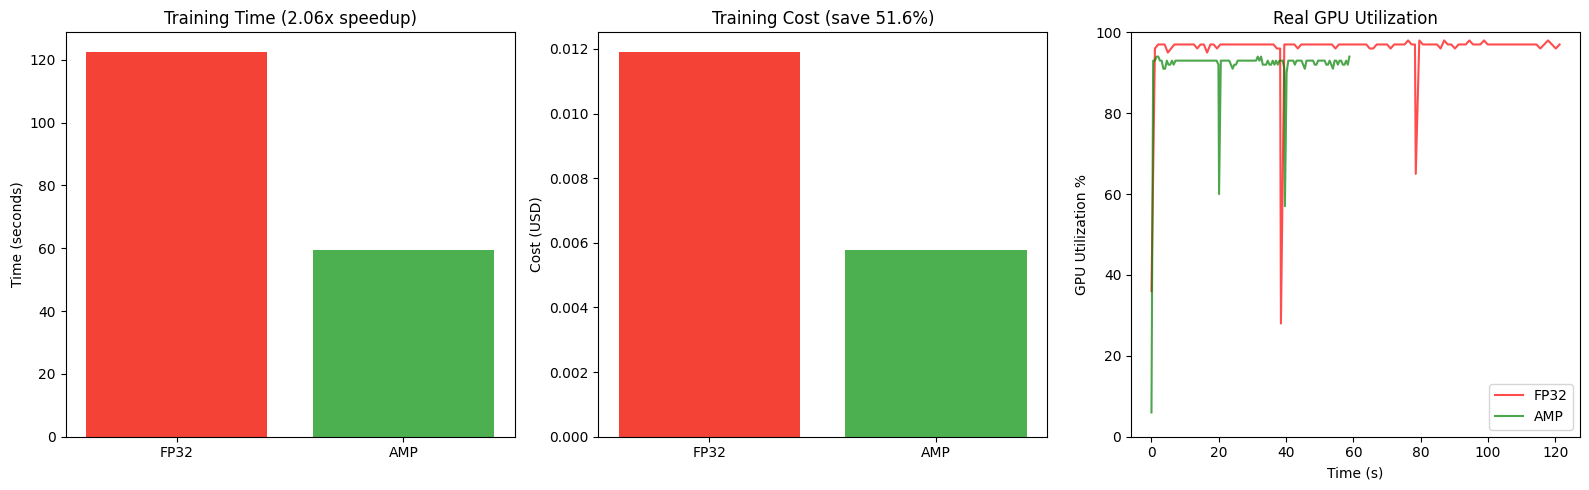

In [47]:
# Cell 24: Compare FP32 vs AMP - FinOps Analysis
print("=" * 60)
print("FINOPS COMPARISON: FP32 vs Mixed Precision (AMP)")
print("=" * 60)

speedup = fp32_total_time / amp_total_time
cost_saving = fp32_cost - amp_cost
cost_saving_pct = (cost_saving / fp32_cost) * 100 if fp32_cost > 0 else 0
mem_saving = fp32_peak_mem - amp_peak_mem

print(f"\n{'Metric':<25} {'FP32':<15} {'AMP':<15} {'Improvement'}")
print("-" * 70)
print(f"{'Total Time':<25} {fp32_total_time:<15.1f} {amp_total_time:<15.1f} {speedup:.2f}x faster")
print(f"{'Peak Memory (GB)':<25} {fp32_peak_mem:<15.2f} {amp_peak_mem:<15.2f} {mem_saving:.2f} GB saved")
print(f"{'Cost (USD)':<25} ${fp32_cost:<14.6f} ${amp_cost:<14.6f} ${cost_saving:.6f} saved")
print(f"{'Cost Saving %':<25} {'---':<15} {'---':<15} {cost_saving_pct:.1f}%")

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    print(f"{'Avg GPU Util %':<25} {fp32_monitor_df['gpu_util_pct'].mean():<15.1f} {amp_monitor_df['gpu_util_pct'].mean():<15.1f}")
    print(f"{'Avg Power (W)':<25} {fp32_monitor_df['power_watts'].mean():<15.1f} {amp_monitor_df['power_watts'].mean():<15.1f}")

# Extrapolate to larger scale
print(f"\n--- Extrapolated Savings at Scale ---")
for scale_name, hours in [("1 day training", 24), ("1 week training", 168), ("1 month training", 720)]:
    fp32_scaled = hours * price_per_hour
    amp_scaled = (hours / speedup) * price_per_hour
    saved = fp32_scaled - amp_scaled
    print(f"   {scale_name}: FP32=${fp32_scaled:.2f} vs AMP=${amp_scaled:.2f} -> SAVE ${saved:.2f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar: Time comparison
axes[0].bar(['FP32', 'AMP'], [fp32_total_time, amp_total_time], color=['#F44336', '#4CAF50'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title(f'Training Time ({speedup:.2f}x speedup)')

# Bar: Cost comparison
axes[1].bar(['FP32', 'AMP'], [fp32_cost, amp_cost], color=['#F44336', '#4CAF50'])
axes[1].set_ylabel('Cost (USD)')
axes[1].set_title(f'Training Cost (save {cost_saving_pct:.1f}%)')

# Line: GPU utilization over time (both experiments) or epoch time
if has_monitor_data:
    if not fp32_monitor_df.empty:
        axes[2].plot(fp32_monitor_df['elapsed'], fp32_monitor_df['gpu_util_pct'], 'r-', alpha=0.7, label='FP32')
    if not amp_monitor_df.empty:
        axes[2].plot(amp_monitor_df['elapsed'], amp_monitor_df['gpu_util_pct'], 'g-', alpha=0.7, label='AMP')
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('GPU Utilization %')
    axes[2].set_title('Real GPU Utilization')
    axes[2].legend()
    axes[2].set_ylim(0, 100)
else:
    # Fallback: show epoch times
    epochs = list(range(1, NUM_EPOCHS + 1))
    axes[2].plot(epochs, [r['time_s'] for r in fp32_results], 'r-o', label='FP32')
    axes[2].plot(epochs, [r['time_s'] for r in amp_results], 'g-o', label='AMP')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Time (s)')
    axes[2].set_title('Time per Epoch')
    axes[2].legend()

plt.tight_layout()
plt.savefig('real_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [49]:
# Cell 25: Report real GPU costs back to the FinOps Gateway
print("=" * 60)
print("REPORTING REAL GPU COSTS TO FINOPS GATEWAY")
print("=" * 60)

# Report FP32 workload
fp32_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-fp32",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": fp32_total_time,
    "is_spot": False,
    "project": "real-gpu-lab",
}).json()
print(f"\n   FP32 workload reported:")
print(f"   Cost: ${fp32_report['total_cost_usd']:.6f} | Rate: ${fp32_report['rate_per_hour']:.4f}/hr")

# Report AMP workload (as spot - demonstrating cost optimization)
amp_report = requests.post(f"{GATEWAY_URL}/billing/record", json={
    "workload_id": "real-gpu-resnet18-amp",
    "gpu_type": detected_type,
    "gpu_count": 1,
    "duration_seconds": amp_total_time,
    "is_spot": True,
    "project": "real-gpu-lab",
}).json()
print(f"\n   AMP workload reported (as spot):")
print(f"   Cost: ${amp_report['total_cost_usd']:.6f} | Saved: ${amp_report['savings_usd']:.6f}")

# Submit workload info to cluster tracker
for wl_name, wl_time in [("real-gpu-resnet18-fp32", fp32_total_time), ("real-gpu-resnet18-amp", amp_total_time)]:
    requests.post(f"{GATEWAY_URL}/cluster/workloads/submit", json={
        "workload_id": wl_name,
        "gpu_type_preferred": detected_type,
        "gpu_count": 1,
        "duration_seconds": int(wl_time),
    })

# Get updated billing summary including real GPU data
print(f"\n--- Updated FinOps Billing (incl. real GPU) ---")
summary = requests.get(f"{GATEWAY_URL}/billing/summary", params={"project": "real-gpu-lab"}).json()
print(f"   Project:         real-gpu-lab")
print(f"   Total Cost:      ${summary['total_cost_usd']:.6f}")
print(f"   Total Savings:   ${summary['total_savings_usd']:.6f}")
print(f"   Workloads:       {summary['total_workloads']}")

# Push real GPU metrics as a cost snapshot
snap = requests.post(f"{GATEWAY_URL}/cost/snapshot").json()
print(f"\n   Cost snapshot taken: waste={snap['waste_pct']:.1f}%")

# Get final dashboard with everything
print(f"\n--- FINAL DASHBOARD (Mock + Real GPU) ---")
dash = requests.get(f"{GATEWAY_URL}/cost/dashboard").json()
bs = dash.get('billing_summary', {})
print(f"   Total Platform Cost:  ${bs.get('total_cost_usd', 0):.4f}")
print(f"   Total Savings:        ${bs.get('total_savings_usd', 0):.4f}")
print(f"   Budget Utilization:   {bs.get('budget_utilization_pct', 0):.1f}%")
print(f"   Alert:                {bs.get('alert', 'N/A')}")

REPORTING REAL GPU COSTS TO FINOPS GATEWAY

   FP32 workload reported:
   Cost: $0.011900 | Rate: $0.3500/hr

   AMP workload reported (as spot):
   Cost: $0.001700 | Saved: $0.004000

--- Updated FinOps Billing (incl. real GPU) ---
   Project:         real-gpu-lab
   Total Cost:      $0.013600
   Total Savings:   $0.004000
   Workloads:       2

   Cost snapshot taken: waste=22.1%

--- FINAL DASHBOARD (Mock + Real GPU) ---
   Total Platform Cost:  $1.3640
   Total Savings:        $1.4151
   Budget Utilization:   1.4%
   Alert:                OK


In [50]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


Real GPU Telemetry During Training


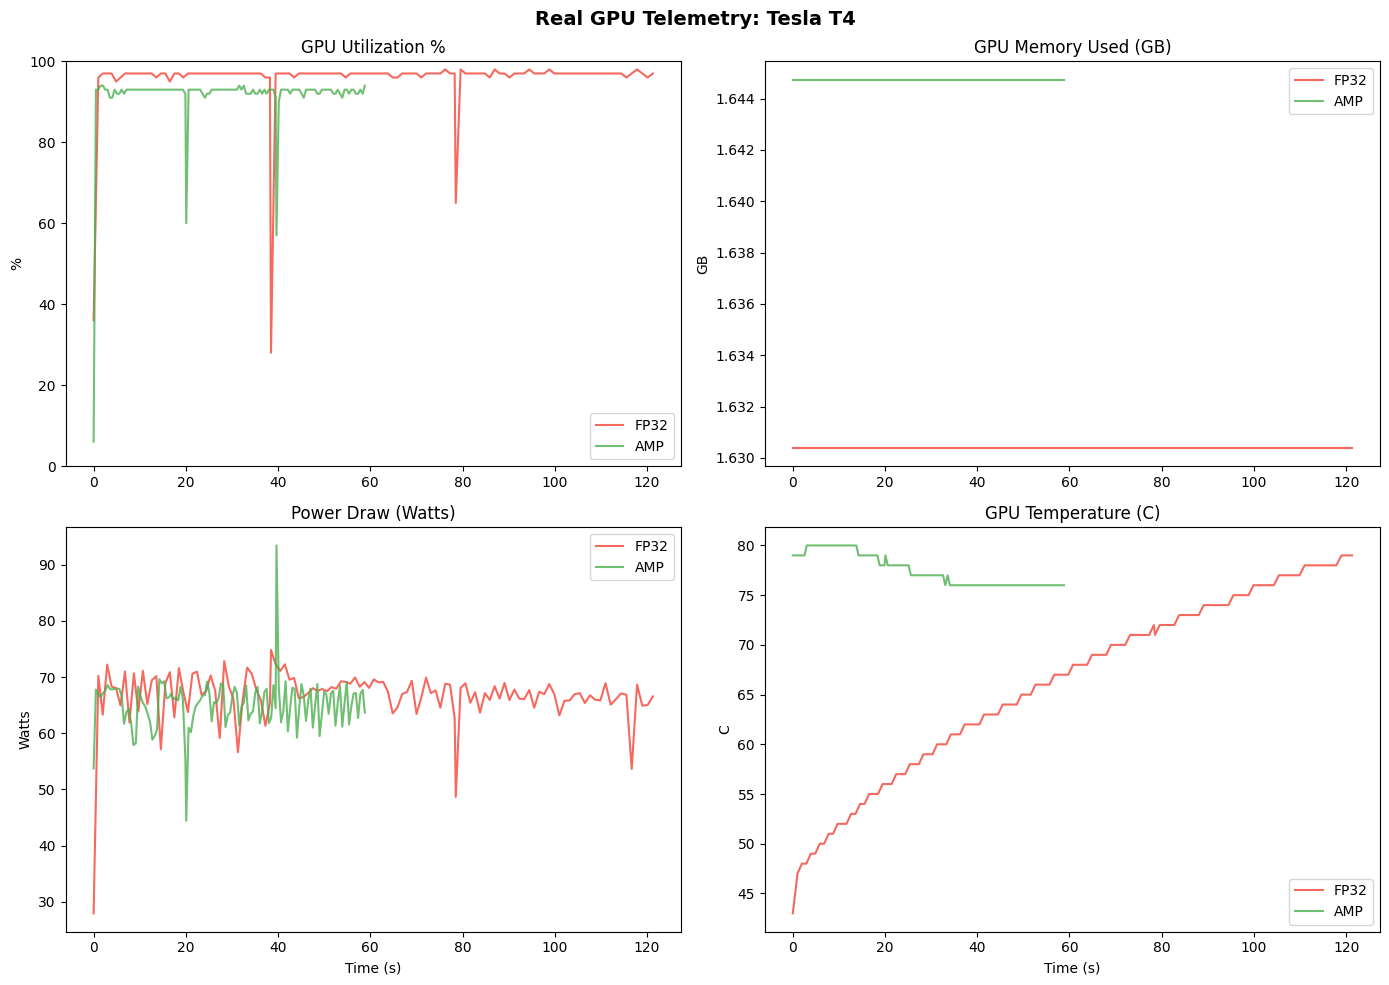

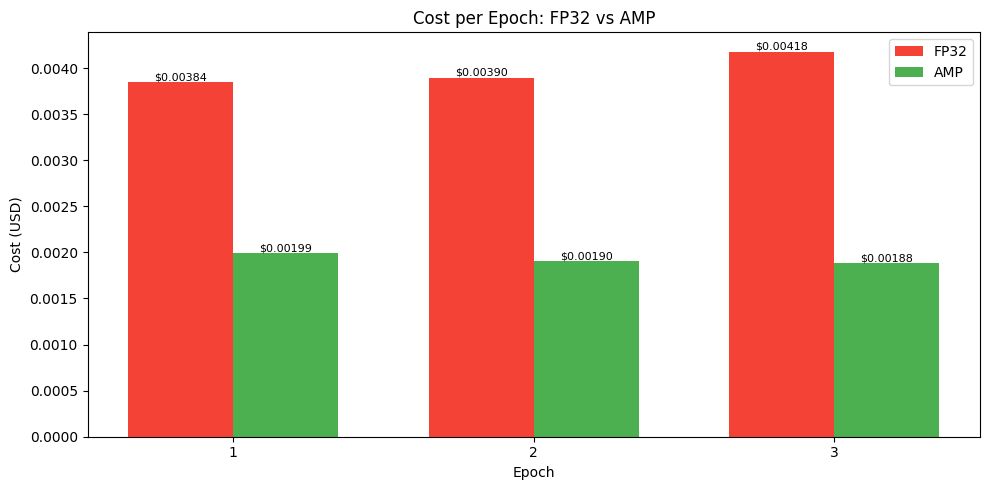


Charts saved: cost_per_epoch.png, real_gpu_telemetry.png


In [51]:
# Cell 26: Real GPU Monitoring Visualization
print("Real GPU Telemetry During Training")
print("=" * 60)

has_monitor_data = (not fp32_monitor_df.empty and 'gpu_util_pct' in fp32_monitor_df.columns
                    and not amp_monitor_df.empty and 'gpu_util_pct' in amp_monitor_df.columns)

if has_monitor_data:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # GPU Utilization
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 0].plot(df['elapsed'], df['gpu_util_pct'], color=color, alpha=0.8, label=label)
    axes[0, 0].set_title('GPU Utilization %')
    axes[0, 0].set_ylabel('%')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 100)

    # Memory Usage
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[0, 1].plot(df['elapsed'], df['mem_used_mb'] / 1024, color=color, alpha=0.8, label=label)
    axes[0, 1].set_title('GPU Memory Used (GB)')
    axes[0, 1].set_ylabel('GB')
    axes[0, 1].legend()

    # Power Draw
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 0].plot(df['elapsed'], df['power_watts'], color=color, alpha=0.8, label=label)
    axes[1, 0].set_title('Power Draw (Watts)')
    axes[1, 0].set_ylabel('Watts')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].legend()

    # Temperature
    for label, df, color in [("FP32", fp32_monitor_df, '#F44336'), ("AMP", amp_monitor_df, '#4CAF50')]:
        if not df.empty:
            axes[1, 1].plot(df['elapsed'], df['temp_c'], color=color, alpha=0.8, label=label)
    axes[1, 1].set_title('GPU Temperature (C)')
    axes[1, 1].set_ylabel('C')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].legend()

    plt.suptitle(f'Real GPU Telemetry: {gpu_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('real_gpu_telemetry.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("   GPU telemetry not available (monitor collected 0 samples).")
    print("   Showing epoch-level metrics instead.\n")

# Cost per epoch chart (always works)
fig, ax = plt.subplots(figsize=(10, 5))
fp32_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in fp32_results]
amp_epoch_costs = [(r['time_s'] / 3600) * price_per_hour for r in amp_results]
epochs = list(range(1, NUM_EPOCHS + 1))

x = range(len(epochs))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], fp32_epoch_costs, width, label='FP32', color='#F44336')
bars2 = ax.bar([i + width/2 for i in x], amp_epoch_costs, width, label='AMP', color='#4CAF50')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cost (USD)')
ax.set_title('Cost per Epoch: FP32 vs AMP')
ax.set_xticks(x)
ax.set_xticklabels(epochs)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'${bar.get_height():.5f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cost_per_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCharts saved: cost_per_epoch.png" + (", real_gpu_telemetry.png" if has_monitor_data else ""))

In [52]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


---
## Part 8.5: Advanced GPU Cost Optimization
Apply advanced FinOps techniques: multi-GPU cost analysis, project forecasting, and optimization strategy prioritization.

This section extends Part 8 with:
1. **Multi-GPU Cost Analysis** - Compare scaling efficiency and determine optimal GPU count
2. **Project Cost Forecasting** - Forecast multi-phase project costs with confidence intervals
3. **Optimization Opportunity Analysis** - Prioritize and combine optimization strategies

In [53]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


EXERCISE 8.5.1: Multi-GPU Cost Analysis

GPU type: A100 ($3.67/GPU-hour)
Single-GPU baseline: 2.00 hours


,GPUs,Speedup,Efficiency %,Training Hours,Time Saved %,GPU Hours,Total Cost ($),Cost per Speedup Unit ($)
0,1,1.00x,100.0%,2.00,0.0%,2.00,$7.34,$7.34
1,2,1.80x,90.0%,1.11,44.4%,2.22,$8.16,$4.53
2,4,3.20x,80.0%,0.62,68.8%,2.50,$9.18,$2.87
3,8,5.60x,70.0%,0.36,82.1%,2.86,$10.49,$1.87



Best cost-performance configuration:
   8x A100 | 0.36h | $10.49 | 70.0% scaling efficiency


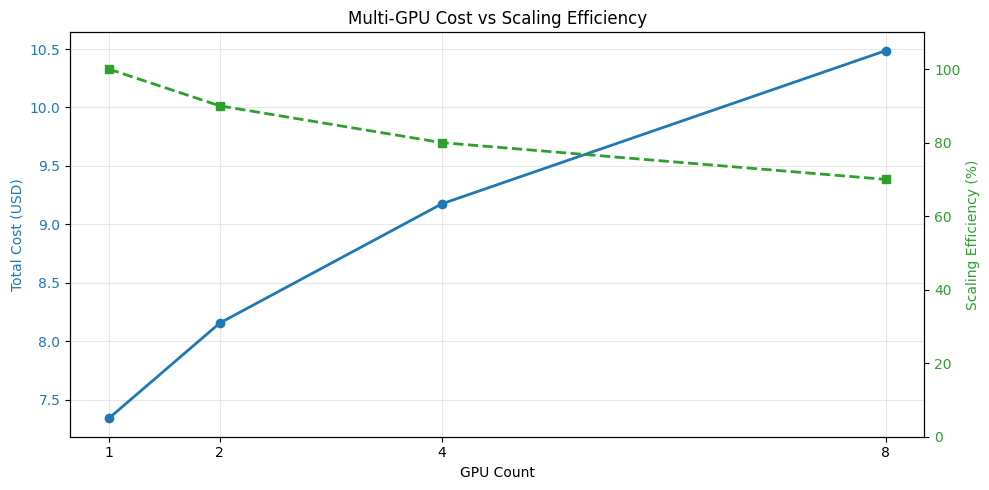


Saved chart: multi_gpu_scaling.png


In [54]:
# Cell 27: Multi-GPU Cost Analysis
print("=" * 60)
print("EXERCISE 8.5.1: Multi-GPU Cost Analysis")
print("=" * 60)

import pandas as pd
import matplotlib.pyplot as plt

if "GPU_PRICING" not in globals():
    GPU_PRICING = {"T4": 0.35, "A100": 3.67, "V100": 2.48, "P100": 1.46, "L4": 0.81}


def _default_speedup_for_count(gpu_count):
    """Realistic sub-linear speedups for data/model parallel training."""
    default_speedups = {1: 1.0, 2: 1.8, 4: 3.2, 8: 5.6, 16: 9.0}
    return default_speedups.get(gpu_count, max(1.0, gpu_count ** 0.85))


def analyze_multi_gpu_cost(base_time_hours, gpu_type, gpu_counts, scaling_factors=None):
    """
    Analyze training time, total cost, and cost efficiency across GPU counts.

    Parameters:
        base_time_hours (float): Single-GPU training time in hours
        gpu_type (str): GPU type (T4, A100, etc.)
        gpu_counts (list): GPU counts to analyze, e.g. [1, 2, 4, 8]
        scaling_factors (dict, optional): Speedup factors by GPU count

    Returns:
        dict: Analysis with rows, a DataFrame, and optimal configurations
    """
    if gpu_type not in GPU_PRICING:
        raise ValueError(f"Unknown GPU type '{gpu_type}'. Available: {sorted(GPU_PRICING)}")

    price_per_gpu_hour = GPU_PRICING[gpu_type]
    rows = []

    for gpu_count in sorted(gpu_counts):
        if gpu_count <= 0:
            raise ValueError(f"GPU count must be positive, got {gpu_count}")

        if scaling_factors and gpu_count in scaling_factors:
            speedup_factor = float(scaling_factors[gpu_count])
        else:
            speedup_factor = float(_default_speedup_for_count(gpu_count))

        speedup_factor = max(0.01, min(speedup_factor, float(gpu_count)))
        training_time_hours = base_time_hours / speedup_factor
        gpu_hours = training_time_hours * gpu_count
        total_cost = gpu_hours * price_per_gpu_hour
        scaling_efficiency = speedup_factor / gpu_count

        rows.append({
            "gpu_count": gpu_count,
            "gpu_type": gpu_type,
            "speedup_factor": speedup_factor,
            "scaling_efficiency": scaling_efficiency,
            "scaling_efficiency_pct": scaling_efficiency * 100,
            "training_time_hours": training_time_hours,
            "time_reduction_pct": (1 - training_time_hours / base_time_hours) * 100,
            "gpu_hours": gpu_hours,
            "total_cost": total_cost,
            "cost_per_speedup_unit": total_cost / speedup_factor,
            "throughput_per_dollar": speedup_factor / total_cost if total_cost else 0,
        })

    df = pd.DataFrame(rows)
    optimal_by_cost = df.loc[df["total_cost"].idxmin()].to_dict()
    optimal_by_speed = df.loc[df["training_time_hours"].idxmin()].to_dict()
    optimal_by_cost_perf = df.loc[df["cost_per_speedup_unit"].idxmin()].to_dict()

    return {
        "gpu_type": gpu_type,
        "price_per_gpu_hour": price_per_gpu_hour,
        "base_time_hours": base_time_hours,
        "rows": rows,
        "dataframe": df,
        "optimal_by_cost": optimal_by_cost,
        "optimal_by_speed": optimal_by_speed,
        "optimal_by_cost_performance": optimal_by_cost_perf,
    }


# Test data
base_training_time = 2.0  # hours for single GPU
test_gpu_counts = [1, 2, 4, 8]

multi_gpu_analysis = analyze_multi_gpu_cost(base_training_time, "A100", test_gpu_counts)
multi_gpu_df = multi_gpu_analysis["dataframe"]

print(f"\nGPU type: {multi_gpu_analysis['gpu_type']} (${multi_gpu_analysis['price_per_gpu_hour']:.2f}/GPU-hour)")
print(f"Single-GPU baseline: {base_training_time:.2f} hours")

display_cols = [
    "gpu_count", "speedup_factor", "scaling_efficiency_pct", "training_time_hours",
    "time_reduction_pct", "gpu_hours", "total_cost", "cost_per_speedup_unit"
]
formatted_multi_gpu = multi_gpu_df[display_cols].rename(columns={
    "gpu_count": "GPUs",
    "speedup_factor": "Speedup",
    "scaling_efficiency_pct": "Efficiency %",
    "training_time_hours": "Training Hours",
    "time_reduction_pct": "Time Saved %",
    "gpu_hours": "GPU Hours",
    "total_cost": "Total Cost ($)",
    "cost_per_speedup_unit": "Cost per Speedup Unit ($)",
})
display(formatted_multi_gpu.style.format({
    "Speedup": "{:.2f}x",
    "Efficiency %": "{:.1f}%",
    "Training Hours": "{:.2f}",
    "Time Saved %": "{:.1f}%",
    "GPU Hours": "{:.2f}",
    "Total Cost ($)": "${:.2f}",
    "Cost per Speedup Unit ($)": "${:.2f}",
}))

best_cost_perf = multi_gpu_analysis["optimal_by_cost_performance"]
print("\nBest cost-performance configuration:")
print(f"   {int(best_cost_perf['gpu_count'])}x {multi_gpu_analysis['gpu_type']} | "
      f"{best_cost_perf['training_time_hours']:.2f}h | ${best_cost_perf['total_cost']:.2f} | "
      f"{best_cost_perf['scaling_efficiency_pct']:.1f}% scaling efficiency")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(multi_gpu_df["gpu_count"], multi_gpu_df["total_cost"], marker="o", linewidth=2, color="#1f77b4")
ax1.set_xlabel("GPU Count")
ax1.set_ylabel("Total Cost (USD)", color="#1f77b4")
ax1.tick_params(axis="y", labelcolor="#1f77b4")
ax1.set_xticks(multi_gpu_df["gpu_count"])
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(multi_gpu_df["gpu_count"], multi_gpu_df["scaling_efficiency_pct"], marker="s", linewidth=2, linestyle="--", color="#2ca02c")
ax2.set_ylabel("Scaling Efficiency (%)", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")
ax2.set_ylim(0, 110)

plt.title("Multi-GPU Cost vs Scaling Efficiency")
fig.tight_layout()
fig.savefig("multi_gpu_scaling.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved chart: multi_gpu_scaling.png")

In [55]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


EXERCISE 8.5.2: Project Cost Forecasting

Phase-by-phase cost forecast:


,Phase,GPU,Count,Hours,Expected Cost ($),Uncertainty,Best Case ($),Worst Case ($)
0,Data Preparation,T4,1,40.0,$14.00,15%,$11.90,$16.10
1,Model Training,A100,4,120.0,$1761.60,25%,$1321.20,$2202.00
2,Hyperparameter Tuning,A100,8,60.0,$1761.60,30%,$1233.12,$2290.08
3,Model Evaluation,T4,2,20.0,$14.00,10%,$12.60,$15.40



Project forecast summary:
   Base expected cost:        $3551.20
   Contingency (20%):       $710.24
   Forecast with buffer:      $4261.44
   95% confidence interval: $3573.51 - $4949.37
   Best / worst case:         $3289.06 - $5233.82


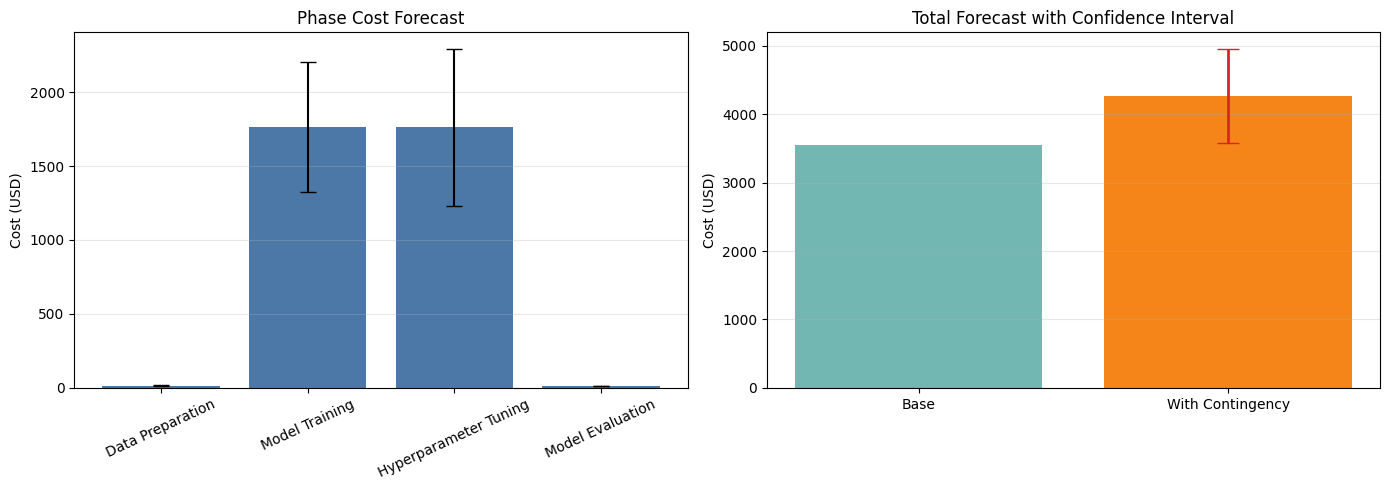


Saved chart: project_forecast.png


In [56]:
# Cell 28: Project Cost Forecasting
print("=" * 60)
print("EXERCISE 8.5.2: Project Cost Forecasting")
print("=" * 60)

import math
from statistics import NormalDist


def _confidence_z_score(confidence_level):
    """Convert a two-sided confidence level to a normal z-score."""
    confidence_level = min(max(float(confidence_level), 0.50), 0.999)
    try:
        return NormalDist().inv_cdf(0.5 + confidence_level / 2)
    except Exception:
        lookup = {0.80: 1.282, 0.90: 1.645, 0.95: 1.960, 0.99: 2.576}
        return lookup.get(round(confidence_level, 2), 1.960)


def forecast_project_cost(phases, contingency_pct=20, confidence_level=0.95):
    """
    Forecast a multi-phase GPU project with contingency and confidence intervals.

    Parameters:
        phases (list): Phase dictionaries containing name, gpu_type, gpu_count,
                       duration_hours, and uncertainty_pct
        contingency_pct (float): Buffer percentage, either 20 or 0.20 style
        confidence_level (float): Two-sided confidence level, e.g. 0.95

    Returns:
        dict: Forecast with base cost, contingency, confidence intervals, and breakdown
    """
    contingency_rate = contingency_pct / 100 if contingency_pct > 1 else contingency_pct
    z_score = _confidence_z_score(confidence_level)
    breakdown = []

    for phase in phases:
        gpu_type = phase["gpu_type"]
        if gpu_type not in GPU_PRICING:
            raise ValueError(f"Unknown GPU type '{gpu_type}'. Available: {sorted(GPU_PRICING)}")

        gpu_count = int(phase["gpu_count"])
        duration_hours = float(phase["duration_hours"])
        uncertainty_pct = float(phase.get("uncertainty_pct", 0.0))
        price_per_gpu_hour = GPU_PRICING[gpu_type]
        base_cost = duration_hours * gpu_count * price_per_gpu_hour
        uncertainty_cost = base_cost * uncertainty_pct
        sigma = uncertainty_cost / z_score if z_score else uncertainty_cost

        breakdown.append({
            "name": phase["name"],
            "gpu_type": gpu_type,
            "gpu_count": gpu_count,
            "duration_hours": duration_hours,
            "price_per_gpu_hour": price_per_gpu_hour,
            "base_cost": base_cost,
            "uncertainty_pct": uncertainty_pct,
            "uncertainty_cost": uncertainty_cost,
            "low_cost": max(0, base_cost - uncertainty_cost),
            "high_cost": base_cost + uncertainty_cost,
            "sigma": sigma,
        })

    base_cost = sum(item["base_cost"] for item in breakdown)
    contingency = base_cost * contingency_rate
    forecast_total = base_cost + contingency
    aggregate_sigma = math.sqrt(sum(item["sigma"] ** 2 for item in breakdown))
    confidence_half_width = z_score * aggregate_sigma
    lower_bound = max(0, base_cost - confidence_half_width) + contingency
    upper_bound = base_cost + confidence_half_width + contingency
    best_case = sum(item["low_cost"] for item in breakdown) + contingency
    worst_case = sum(item["high_cost"] for item in breakdown) + contingency

    phase_df = pd.DataFrame(breakdown)
    return {
        "phases": breakdown,
        "dataframe": phase_df,
        "base_cost": base_cost,
        "contingency_pct": contingency_rate,
        "contingency": contingency,
        "forecast_total": forecast_total,
        "confidence_level": confidence_level,
        "z_score": z_score,
        "confidence_interval": {"lower": lower_bound, "upper": upper_bound, "half_width": confidence_half_width},
        "best_case": best_case,
        "worst_case": worst_case,
    }


# Example project phases
example_project = [
    {"name": "Data Preparation", "gpu_type": "T4", "gpu_count": 1, "duration_hours": 40, "uncertainty_pct": 0.15},
    {"name": "Model Training", "gpu_type": "A100", "gpu_count": 4, "duration_hours": 120, "uncertainty_pct": 0.25},
    {"name": "Hyperparameter Tuning", "gpu_type": "A100", "gpu_count": 8, "duration_hours": 60, "uncertainty_pct": 0.30},
    {"name": "Model Evaluation", "gpu_type": "T4", "gpu_count": 2, "duration_hours": 20, "uncertainty_pct": 0.10},
]

project_forecast = forecast_project_cost(example_project, contingency_pct=20, confidence_level=0.95)
phase_cost_df = project_forecast["dataframe"]

print("\nPhase-by-phase cost forecast:")
display(phase_cost_df[[
    "name", "gpu_type", "gpu_count", "duration_hours", "base_cost",
    "uncertainty_pct", "low_cost", "high_cost"
]].rename(columns={
    "name": "Phase",
    "gpu_type": "GPU",
    "gpu_count": "Count",
    "duration_hours": "Hours",
    "base_cost": "Expected Cost ($)",
    "uncertainty_pct": "Uncertainty",
    "low_cost": "Best Case ($)",
    "high_cost": "Worst Case ($)",
}).style.format({
    "Hours": "{:.1f}",
    "Expected Cost ($)": "${:.2f}",
    "Uncertainty": "{:.0%}",
    "Best Case ($)": "${:.2f}",
    "Worst Case ($)": "${:.2f}",
}))

ci = project_forecast["confidence_interval"]
print("\nProject forecast summary:")
print(f"   Base expected cost:        ${project_forecast['base_cost']:.2f}")
print(f"   Contingency ({project_forecast['contingency_pct']:.0%}):       ${project_forecast['contingency']:.2f}")
print(f"   Forecast with buffer:      ${project_forecast['forecast_total']:.2f}")
print(f"   {project_forecast['confidence_level']:.0%} confidence interval: ${ci['lower']:.2f} - ${ci['upper']:.2f}")
print(f"   Best / worst case:         ${project_forecast['best_case']:.2f} - ${project_forecast['worst_case']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
phase_names = phase_cost_df["name"]
base_costs = phase_cost_df["base_cost"]
uncertainty_costs = phase_cost_df["uncertainty_cost"]

axes[0].bar(phase_names, base_costs, yerr=uncertainty_costs, capsize=6, color="#4c78a8")
axes[0].set_title("Phase Cost Forecast")
axes[0].set_ylabel("Cost (USD)")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(["Base", "With Contingency"], [project_forecast["base_cost"], project_forecast["forecast_total"]], color=["#72b7b2", "#f58518"])
axes[1].errorbar(
    [1], [project_forecast["forecast_total"]],
    yerr=[[project_forecast["forecast_total"] - ci["lower"]], [ci["upper"] - project_forecast["forecast_total"]]],
    fmt="none", ecolor="#d62728", capsize=8, linewidth=2,
)
axes[1].set_title("Total Forecast with Confidence Interval")
axes[1].set_ylabel("Cost (USD)")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig("project_forecast.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved chart: project_forecast.png")

In [57]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis

Current baseline cost: $1468.00

Prioritized recommendations:


,Strategy,Savings %,Potential Savings ($),Effort,Risk,Priority Score,Roadmap Bucket
0,Switch to Mixed Precision (AMP),25%,$367.00,LOW,LOW,367.0,Quick Win
1,Optimize Batch Size,15%,$220.20,LOW,LOW,220.2,Quick Win
2,Use Spot Instances,60%,$880.80,MEDIUM,HIGH,200.2,Strategic Project
3,Implement Early Stopping,20%,$293.60,MEDIUM,LOW,146.8,Planned Improvement
4,Switch to More Efficient GPU Type,40%,$587.20,HIGH,MEDIUM,130.5,Strategic Project



Implementation roadmap with multiplicative savings:


,Step,Strategy,Incremental Savings ($),Cumulative Savings %,Remaining Cost ($)
0,1,Switch to Mixed Precision (AMP),$367.00,25.0%,$1101.00
1,2,Optimize Batch Size,$165.15,36.2%,$935.85
2,3,Use Spot Instances,$561.51,74.5%,$374.34
3,4,Implement Early Stopping,$74.87,79.6%,$299.47
4,5,Switch to More Efficient GPU Type,$119.79,87.8%,$179.68



Final cost if all strategies are applied: $179.68
Total cumulative savings: $1288.32 (87.8%)


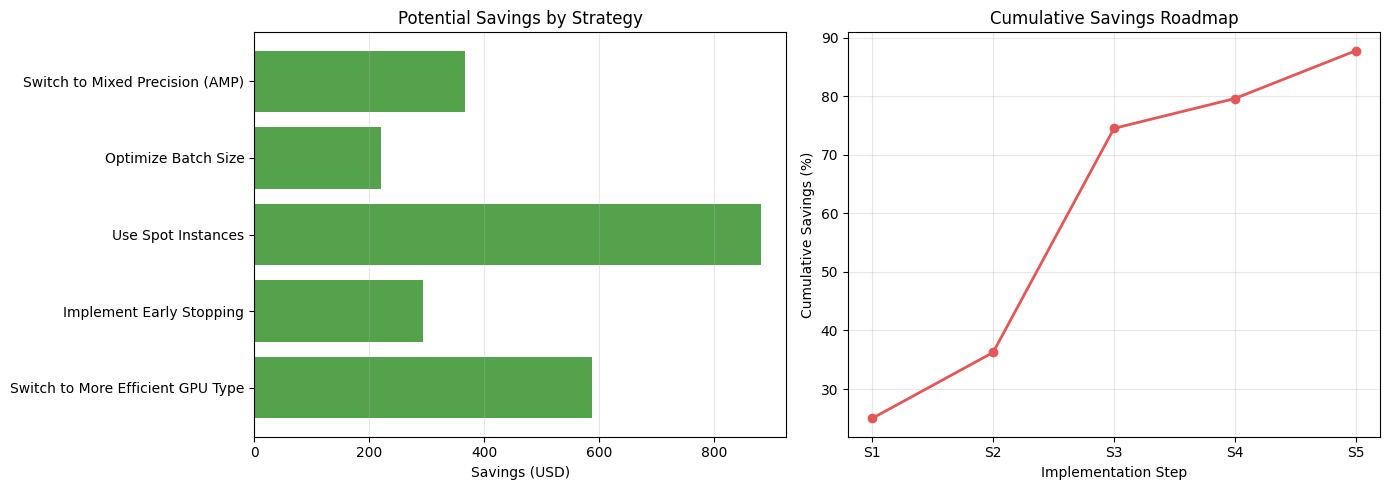


Saved chart: optimization_roadmap.png


In [58]:
# Cell 29: Optimization Opportunity Analysis
print("=" * 60)
print("EXERCISE 8.5.3: Advanced Optimization Opportunity Analysis")
print("=" * 60)

EFFORT_WEIGHTS = {"LOW": 1, "MEDIUM": 2, "HIGH": 3}
RISK_WEIGHTS = {"LOW": 1.0, "MEDIUM": 1.5, "HIGH": 2.2}


def analyze_optimization_opportunities(current_config, optimization_strategies):
    """
    Analyze and prioritize optimization strategies by savings, effort, risk, and dependencies.

    Parameters:
        current_config (dict): Current training configuration
        optimization_strategies (list): Strategy dictionaries with name, savings_pct,
                                        implementation_effort, risk_level, dependencies

    Returns:
        dict: Prioritized recommendations and a cumulative savings roadmap
    """
    gpu_type = current_config["gpu_type"]
    if gpu_type not in GPU_PRICING:
        raise ValueError(f"Unknown GPU type '{gpu_type}'. Available: {sorted(GPU_PRICING)}")

    baseline_cost = (
        float(current_config["duration_hours"])
        * int(current_config["gpu_count"])
        * GPU_PRICING[gpu_type]
    )

    evaluated = []
    for strategy in optimization_strategies:
        savings_pct = float(strategy["savings_pct"])
        effort = strategy.get("implementation_effort", "MEDIUM").upper()
        risk = strategy.get("risk_level", "MEDIUM").upper()
        dependencies = strategy.get("dependencies", [])
        effort_score = EFFORT_WEIGHTS.get(effort, 2)
        risk_score = RISK_WEIGHTS.get(risk, 1.5)
        dependency_penalty = 1 + 0.25 * len(dependencies)
        potential_savings = baseline_cost * savings_pct
        priority_score = potential_savings / (effort_score * risk_score * dependency_penalty)

        if effort == "LOW" and risk == "LOW":
            roadmap_bucket = "Quick Win"
        elif savings_pct >= 0.40:
            roadmap_bucket = "Strategic Project"
        else:
            roadmap_bucket = "Planned Improvement"

        evaluated.append({
            "name": strategy["name"],
            "savings_pct": savings_pct,
            "potential_savings": potential_savings,
            "implementation_effort": effort,
            "effort_score": effort_score,
            "risk_level": risk,
            "risk_score": risk_score,
            "dependencies": dependencies,
            "priority_score": priority_score,
            "roadmap_bucket": roadmap_bucket,
        })

    remaining = sorted(evaluated, key=lambda item: item["priority_score"], reverse=True)
    ordered = []
    completed_names = set()
    while remaining:
        ready = [item for item in remaining if all(dep in completed_names for dep in item["dependencies"])]
        candidates = ready if ready else remaining
        next_item = max(candidates, key=lambda item: (item["priority_score"], -item["effort_score"], -item["risk_score"]))
        ordered.append(next_item)
        completed_names.add(next_item["name"])
        remaining.remove(next_item)

    roadmap = []
    remaining_cost = baseline_cost
    for step, item in enumerate(ordered, start=1):
        incremental_savings = remaining_cost * item["savings_pct"]
        remaining_cost -= incremental_savings
        cumulative_savings = baseline_cost - remaining_cost
        roadmap_item = dict(item)
        roadmap_item.update({
            "step": step,
            "incremental_savings": incremental_savings,
            "remaining_cost": remaining_cost,
            "cumulative_savings": cumulative_savings,
            "cumulative_savings_pct": cumulative_savings / baseline_cost if baseline_cost else 0,
        })
        roadmap.append(roadmap_item)

    ranked_df = pd.DataFrame(sorted(evaluated, key=lambda item: item["priority_score"], reverse=True))
    roadmap_df = pd.DataFrame(roadmap)
    return {
        "baseline_cost": baseline_cost,
        "ranked_recommendations": sorted(evaluated, key=lambda item: item["priority_score"], reverse=True),
        "roadmap": roadmap,
        "dataframe": ranked_df,
        "roadmap_dataframe": roadmap_df,
        "final_cost_after_all": remaining_cost,
        "total_cumulative_savings": baseline_cost - remaining_cost,
        "total_cumulative_savings_pct": (baseline_cost - remaining_cost) / baseline_cost if baseline_cost else 0,
    }


# Example optimization strategies
example_strategies = [
    {"name": "Switch to Mixed Precision (AMP)", "savings_pct": 0.25, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Use Spot Instances", "savings_pct": 0.60, "implementation_effort": "MEDIUM", "risk_level": "HIGH", "dependencies": []},
    {"name": "Optimize Batch Size", "savings_pct": 0.15, "implementation_effort": "LOW", "risk_level": "LOW", "dependencies": []},
    {"name": "Implement Early Stopping", "savings_pct": 0.20, "implementation_effort": "MEDIUM", "risk_level": "LOW", "dependencies": []},
    {"name": "Switch to More Efficient GPU Type", "savings_pct": 0.40, "implementation_effort": "HIGH", "risk_level": "MEDIUM", "dependencies": []},
]

current_training_config = {
    "gpu_type": "A100",
    "gpu_count": 4,
    "duration_hours": 100,
    "precision": "FP32",
    "instance_type": "on-demand",
}

optimization_recommendations = analyze_optimization_opportunities(current_training_config, example_strategies)
ranked_df = optimization_recommendations["dataframe"]
roadmap_df = optimization_recommendations["roadmap_dataframe"]

print(f"\nCurrent baseline cost: ${optimization_recommendations['baseline_cost']:.2f}")
print("\nPrioritized recommendations:")
display(ranked_df[[
    "name", "savings_pct", "potential_savings", "implementation_effort",
    "risk_level", "priority_score", "roadmap_bucket"
]].rename(columns={
    "name": "Strategy",
    "savings_pct": "Savings %",
    "potential_savings": "Potential Savings ($)",
    "implementation_effort": "Effort",
    "risk_level": "Risk",
    "priority_score": "Priority Score",
    "roadmap_bucket": "Roadmap Bucket",
}).style.format({
    "Savings %": "{:.0%}",
    "Potential Savings ($)": "${:.2f}",
    "Priority Score": "{:.1f}",
}))

print("\nImplementation roadmap with multiplicative savings:")
display(roadmap_df[[
    "step", "name", "incremental_savings", "cumulative_savings_pct", "remaining_cost"
]].rename(columns={
    "step": "Step",
    "name": "Strategy",
    "incremental_savings": "Incremental Savings ($)",
    "cumulative_savings_pct": "Cumulative Savings %",
    "remaining_cost": "Remaining Cost ($)",
}).style.format({
    "Incremental Savings ($)": "${:.2f}",
    "Cumulative Savings %": "{:.1%}",
    "Remaining Cost ($)": "${:.2f}",
}))

print(f"\nFinal cost if all strategies are applied: ${optimization_recommendations['final_cost_after_all']:.2f}")
print(f"Total cumulative savings: ${optimization_recommendations['total_cumulative_savings']:.2f} "
      f"({optimization_recommendations['total_cumulative_savings_pct']:.1%})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_ranked = ranked_df.sort_values("priority_score", ascending=True)
axes[0].barh(plot_ranked["name"], plot_ranked["potential_savings"], color="#54a24b")
axes[0].set_title("Potential Savings by Strategy")
axes[0].set_xlabel("Savings (USD)")
axes[0].grid(axis="x", alpha=0.3)

axes[1].plot(roadmap_df["step"], roadmap_df["cumulative_savings_pct"] * 100, marker="o", linewidth=2, color="#e45756")
axes[1].set_xticks(roadmap_df["step"])
axes[1].set_xticklabels([f"S{int(step)}" for step in roadmap_df["step"]])
axes[1].set_title("Cumulative Savings Roadmap")
axes[1].set_xlabel("Implementation Step")
axes[1].set_ylabel("Cumulative Savings (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig("optimization_roadmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved chart: optimization_roadmap.png")

In [59]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


EXERCISE 8.5.4: Integrated Cost Dashboard


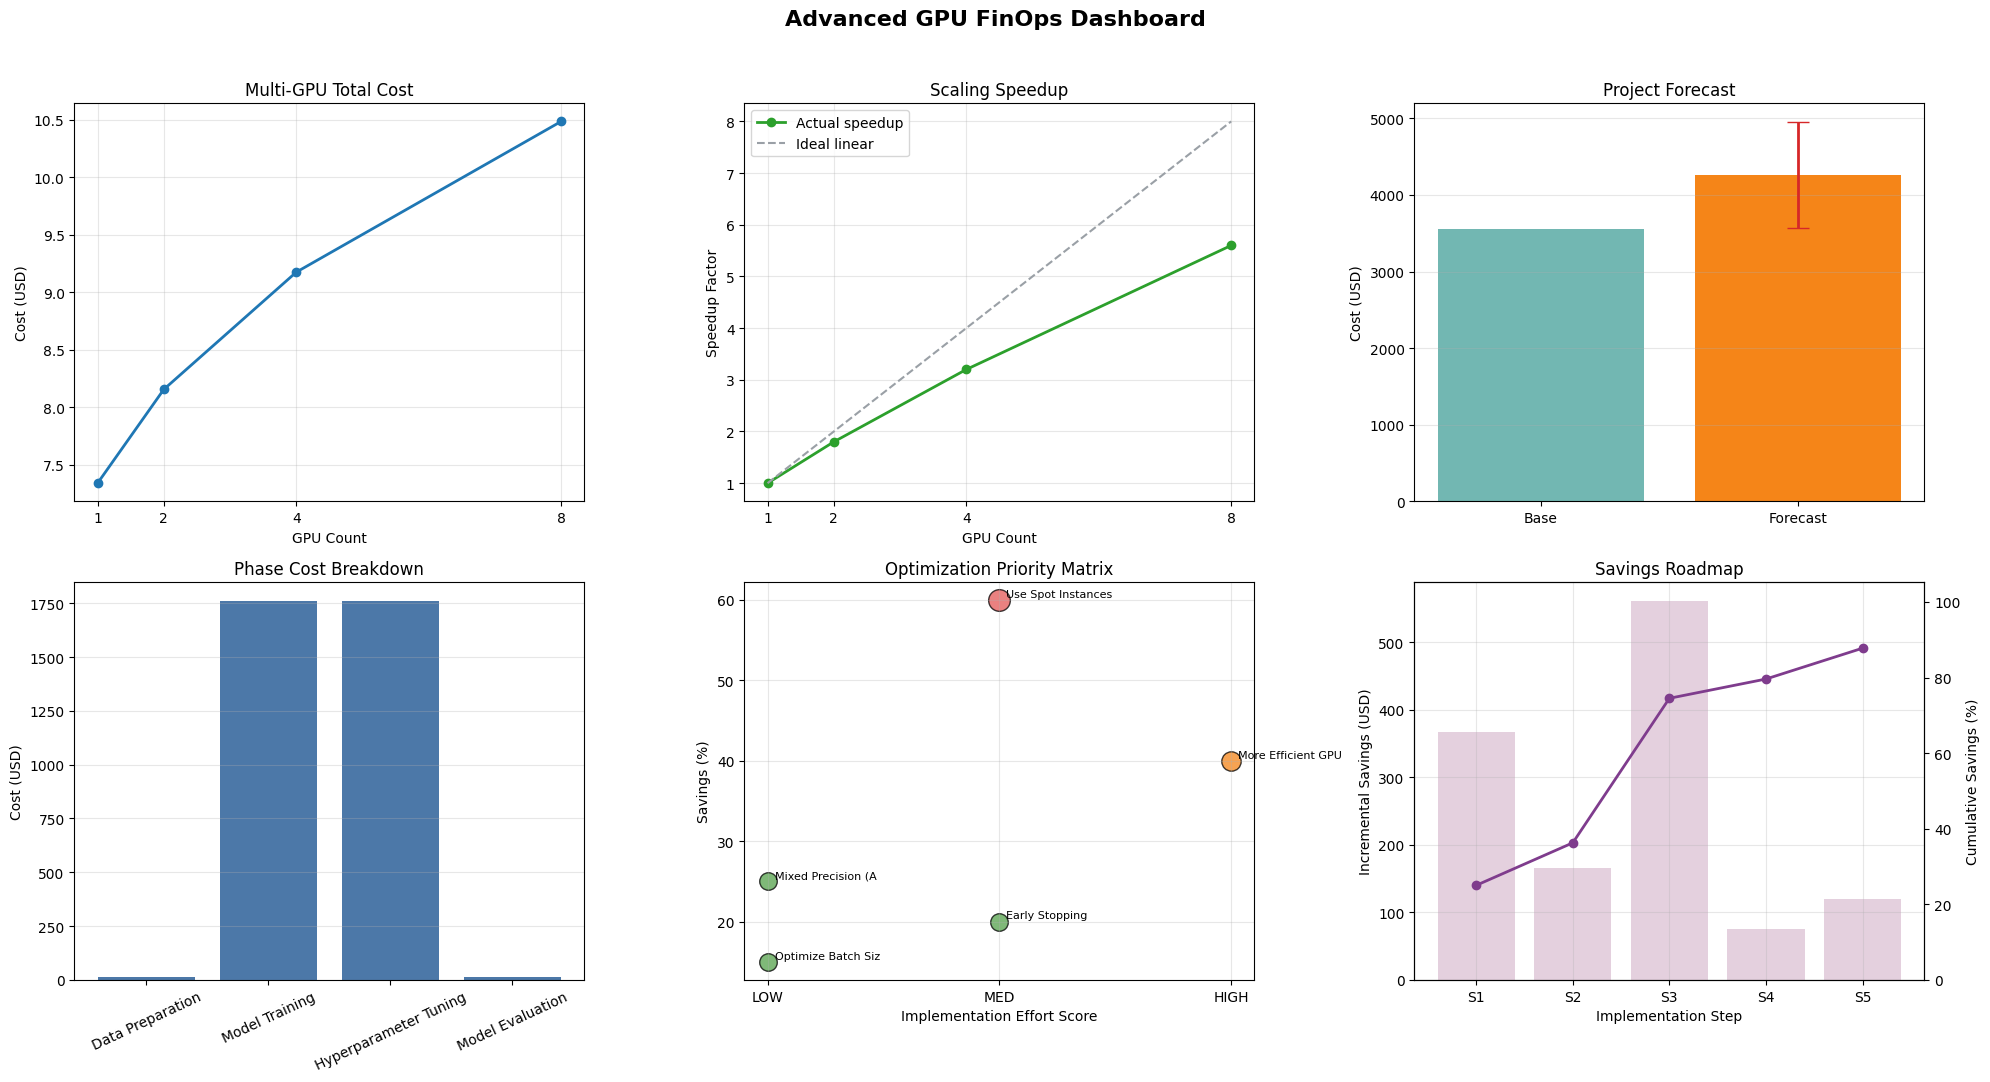


Saved chart: advanced_finops_dashboard.png


In [60]:
# Cell 30: Integrated Cost Dashboard
print("=" * 60)
print("EXERCISE 8.5.4: Integrated Cost Dashboard")
print("=" * 60)


def create_advanced_finops_dashboard(multi_gpu_analysis, project_forecast, optimization_recommendations):
    """
    Create an integrated 2x3 dashboard for the advanced FinOps analyses.

    Parameters:
        multi_gpu_analysis (dict): Results from multi-gpu cost analysis
        project_forecast (dict): Results from project cost forecasting
        optimization_recommendations (dict): Results from optimization analysis

    Returns:
        matplotlib.figure.Figure: Comprehensive dashboard figure
    """
    multi_df = multi_gpu_analysis["dataframe"]
    phase_df = project_forecast["dataframe"]
    opt_df = optimization_recommendations["dataframe"]
    roadmap_df = optimization_recommendations["roadmap_dataframe"]
    ci = project_forecast["confidence_interval"]

    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    fig.suptitle("Advanced GPU FinOps Dashboard", fontsize=16, fontweight="bold")

    # 1. Multi-GPU cost curve
    ax = axes[0, 0]
    ax.plot(multi_df["gpu_count"], multi_df["total_cost"], marker="o", linewidth=2, color="#1f77b4")
    ax.set_title("Multi-GPU Total Cost")
    ax.set_xlabel("GPU Count")
    ax.set_ylabel("Cost (USD)")
    ax.set_xticks(multi_df["gpu_count"])
    ax.grid(True, alpha=0.3)

    # 2. Scaling efficiency and speedup
    ax = axes[0, 1]
    ax.plot(multi_df["gpu_count"], multi_df["speedup_factor"], marker="o", linewidth=2, label="Actual speedup", color="#2ca02c")
    ax.plot(multi_df["gpu_count"], multi_df["gpu_count"], linestyle="--", label="Ideal linear", color="#9aa0a6")
    ax.set_title("Scaling Speedup")
    ax.set_xlabel("GPU Count")
    ax.set_ylabel("Speedup Factor")
    ax.set_xticks(multi_df["gpu_count"])
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3. Project forecast with confidence interval
    ax = axes[0, 2]
    ax.bar(["Base", "Forecast"], [project_forecast["base_cost"], project_forecast["forecast_total"]], color=["#72b7b2", "#f58518"])
    ax.errorbar(
        [1], [project_forecast["forecast_total"]],
        yerr=[[project_forecast["forecast_total"] - ci["lower"]], [ci["upper"] - project_forecast["forecast_total"]]],
        fmt="none", ecolor="#d62728", capsize=8, linewidth=2,
    )
    ax.set_title("Project Forecast")
    ax.set_ylabel("Cost (USD)")
    ax.grid(axis="y", alpha=0.3)

    # 4. Phase cost breakdown
    ax = axes[1, 0]
    ax.bar(phase_df["name"], phase_df["base_cost"], color="#4c78a8")
    ax.set_title("Phase Cost Breakdown")
    ax.set_ylabel("Cost (USD)")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.3)

    # 5. Optimization prioritization matrix
    ax = axes[1, 1]
    colors = {"LOW": "#54a24b", "MEDIUM": "#f58518", "HIGH": "#e45756"}
    for _, row in opt_df.iterrows():
        ax.scatter(
            row["effort_score"], row["savings_pct"] * 100,
            s=90 + row["risk_score"] * 70,
            color=colors.get(row["risk_level"], "#bab0ac"),
            alpha=0.75,
            edgecolor="black",
        )
        short_name = row["name"].replace("Switch to ", "").replace("Implement ", "")[:18]
        ax.annotate(short_name, (row["effort_score"] + 0.03, row["savings_pct"] * 100 + 0.4), fontsize=8)
    ax.set_title("Optimization Priority Matrix")
    ax.set_xlabel("Implementation Effort Score")
    ax.set_ylabel("Savings (%)")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["LOW", "MED", "HIGH"])
    ax.grid(True, alpha=0.3)

    # 6. Cumulative savings roadmap
    ax = axes[1, 2]
    ax.bar(roadmap_df["step"], roadmap_df["incremental_savings"], alpha=0.35, color="#b279a2", label="Incremental savings")
    ax.set_title("Savings Roadmap")
    ax.set_xlabel("Implementation Step")
    ax.set_ylabel("Incremental Savings (USD)")
    ax.set_xticks(roadmap_df["step"])
    ax.set_xticklabels([f"S{int(step)}" for step in roadmap_df["step"]])
    ax.grid(True, alpha=0.3)
    ax_pct = ax.twinx()
    ax_pct.plot(roadmap_df["step"], roadmap_df["cumulative_savings_pct"] * 100, marker="o", linewidth=2, color="#7f3c8d", label="Cumulative savings")
    ax_pct.set_ylabel("Cumulative Savings (%)")
    ax_pct.set_ylim(0, max(100, roadmap_df["cumulative_savings_pct"].max() * 120))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig("advanced_finops_dashboard.png", dpi=150, bbox_inches="tight")
    return fig


advanced_dashboard_fig = create_advanced_finops_dashboard(
    multi_gpu_analysis,
    project_forecast,
    optimization_recommendations,
)
plt.show()
print("\nSaved chart: advanced_finops_dashboard.png")

In [61]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


In [62]:
# Cell 31: Challenge Exercise - Cost Optimization Strategy Design
print("=" * 60)
print("CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy")
print("=" * 60)

# Open-ended scenario combining multi-GPU analysis, project forecasting, and optimization prioritization.
challenge_scenario = {
    "project": "Large Language Model Fine-tuning",
    "requirements": {
        "training_duration": 200,  # hours baseline on the current GPU configuration
        "gpu_type": "A100",
        "gpu_count": 8,
        "precision": "FP32",
        "instance_type": "on-demand",
        "budget": 5000,  # USD
    },
    "constraints": {
        "max_preemption_risk": "MEDIUM",
        "min_accuracy": 0.95,
        "deadline": "2 weeks",
    }
}

requirements = challenge_scenario["requirements"]
constraints = challenge_scenario["constraints"]
budget = requirements["budget"]
deadline_hours = 14 * 24
baseline_gpu_type = requirements["gpu_type"]
baseline_gpu_count = requirements["gpu_count"]
baseline_duration = requirements["training_duration"]
baseline_cost = baseline_duration * baseline_gpu_count * GPU_PRICING[baseline_gpu_type]

print("CHALLENGE SCENARIO:")
print(f"   Project: {challenge_scenario['project']}")
print(f"   Baseline: {baseline_gpu_count}x {baseline_gpu_type} for {baseline_duration}h")
print(f"   Baseline cost: ${baseline_cost:.2f}")
print(f"   Budget: ${budget:.2f}")
print(f"   Deadline: {constraints['deadline']} ({deadline_hours} hours)")

# Convert the 8-GPU baseline into an equivalent single-GPU workload size so we can compare counts.
baseline_speedup = _default_speedup_for_count(baseline_gpu_count)
equivalent_single_gpu_hours = baseline_duration * baseline_speedup
challenge_gpu_analysis = analyze_multi_gpu_cost(
    equivalent_single_gpu_hours,
    baseline_gpu_type,
    [1, 2, 4, 8],
)
challenge_gpu_df = challenge_gpu_analysis["dataframe"].copy()

# Avoid spot instances because the scenario caps preemption risk at MEDIUM.
selected_strategy_names = [
    "Switch to Mixed Precision (AMP)",
    "Optimize Batch Size",
    "Implement Early Stopping",
]
selected_strategies = [item for item in example_strategies if item["name"] in selected_strategy_names]
strategy_multiplier = 1.0
for strategy in selected_strategies:
    strategy_multiplier *= (1 - strategy["savings_pct"])

challenge_gpu_df["optimized_time_hours"] = challenge_gpu_df["training_time_hours"] * strategy_multiplier
challenge_gpu_df["optimized_cost"] = challenge_gpu_df["total_cost"] * strategy_multiplier
challenge_gpu_df["pessimistic_time_hours"] = challenge_gpu_df["optimized_time_hours"] * 1.20
challenge_gpu_df["meets_deadline_with_buffer"] = challenge_gpu_df["pessimistic_time_hours"] <= deadline_hours
challenge_gpu_df["under_budget"] = challenge_gpu_df["optimized_cost"] <= budget
candidate_df = challenge_gpu_df[challenge_gpu_df["meets_deadline_with_buffer"] & challenge_gpu_df["under_budget"]]

if candidate_df.empty:
    selected_gpu_plan = challenge_gpu_df.sort_values(["optimized_cost", "optimized_time_hours"]).iloc[0]
else:
    selected_gpu_plan = candidate_df.sort_values("optimized_cost").iloc[0]

selected_gpu_count = int(selected_gpu_plan["gpu_count"])
selected_duration = float(selected_gpu_plan["optimized_time_hours"])
selected_pre_optimization_cost = float(selected_gpu_plan["total_cost"])
selected_optimized_cost = float(selected_gpu_plan["optimized_cost"])

print("\nGPU count candidates after selected optimizations:")
display(challenge_gpu_df[[
    "gpu_count", "training_time_hours", "total_cost", "optimized_time_hours",
    "pessimistic_time_hours", "optimized_cost", "meets_deadline_with_buffer", "under_budget"
]].rename(columns={
    "gpu_count": "GPUs",
    "training_time_hours": "Baseline Hours",
    "total_cost": "Baseline Cost ($)",
    "optimized_time_hours": "Optimized Hours",
    "pessimistic_time_hours": "20% High Hours",
    "optimized_cost": "Optimized Cost ($)",
    "meets_deadline_with_buffer": "Deadline OK",
    "under_budget": "Budget OK",
}).style.format({
    "Baseline Hours": "{:.1f}",
    "Baseline Cost ($)": "${:.2f}",
    "Optimized Hours": "{:.1f}",
    "20% High Hours": "{:.1f}",
    "Optimized Cost ($)": "${:.2f}",
}))

selected_config = {
    "gpu_type": baseline_gpu_type,
    "gpu_count": selected_gpu_count,
    "duration_hours": selected_gpu_plan["training_time_hours"],
    "precision": "FP32 baseline before optimizations",
    "instance_type": "on-demand",
}
selected_strategy_analysis = analyze_optimization_opportunities(selected_config, selected_strategies)

challenge_project_phases = [
    {
        "name": "Optimized Fine-tuning",
        "gpu_type": baseline_gpu_type,
        "gpu_count": selected_gpu_count,
        "duration_hours": selected_duration,
        "uncertainty_pct": 0.20,
    },
    {
        "name": "Validation and Evaluation",
        "gpu_type": "T4",
        "gpu_count": 2,
        "duration_hours": 24,
        "uncertainty_pct": 0.10,
    },
    {
        "name": "Checkpoint Retry Buffer",
        "gpu_type": baseline_gpu_type,
        "gpu_count": selected_gpu_count,
        "duration_hours": 12,
        "uncertainty_pct": 0.25,
    },
]
challenge_forecast = forecast_project_cost(challenge_project_phases, contingency_pct=15, confidence_level=0.95)
challenge_ci = challenge_forecast["confidence_interval"]

print("\nRecommended optimization strategy:")
print(f"   1. Resize from {baseline_gpu_count}x to {selected_gpu_count}x {baseline_gpu_type}.")
for index, strategy in enumerate(selected_strategies, start=2):
    print(f"   {index}. {strategy['name']} ({strategy['savings_pct']:.0%} estimated savings, "
          f"{strategy['implementation_effort']} effort, {strategy['risk_level']} risk).")
print("   Spot instances are excluded because their HIGH preemption risk violates the MEDIUM risk constraint.")

print("\nCost and schedule impact:")
print(f"   Original baseline cost:             ${baseline_cost:.2f}")
print(f"   Selected GPU plan before tuning:    ${selected_pre_optimization_cost:.2f}")
print(f"   Training cost after optimizations:  ${selected_optimized_cost:.2f}")
print(f"   Optimized training time:            {selected_duration:.1f}h")
print(f"   20% pessimistic duration:           {selected_duration * 1.20:.1f}h / {deadline_hours}h deadline")
print(f"   Forecast with contingency:          ${challenge_forecast['forecast_total']:.2f}")
print(f"   95% confidence interval:            ${challenge_ci['lower']:.2f} - ${challenge_ci['upper']:.2f}")
print(f"   Budget status:                      {'PASS' if challenge_forecast['forecast_total'] <= budget else 'FAIL'}")
print(f"   Upper-bound budget status:          {'PASS' if challenge_ci['upper'] <= budget else 'REVIEW'}")

print("\nJustification:")
print("   The plan keeps on-demand A100 capacity to satisfy the preemption-risk constraint,")
print("   uses low-risk training optimizations first, and chooses the lowest-cost GPU count")
print("   whose 20% pessimistic runtime still fits inside the two-week deadline.")
print("   Mixed precision and batch tuning should be validated against the 0.95 accuracy requirement")
print("   before the final run, with early stopping tied to validation quality rather than raw loss alone.")

CHALLENGE EXERCISE 8.5.5: Design Cost Optimization Strategy
CHALLENGE SCENARIO:
   Project: Large Language Model Fine-tuning
   Baseline: 8x A100 for 200h
   Baseline cost: $5872.00
   Budget: $5000.00
   Deadline: 2 weeks (336 hours)

GPU count candidates after selected optimizations:


,GPUs,Baseline Hours,Baseline Cost ($),Optimized Hours,20% High Hours,Optimized Cost ($),Deadline OK,Budget OK
0,1,1120.0,$4110.40,571.2,685.4,$2096.30,False,True
1,2,622.2,$4567.11,317.3,380.8,$2329.23,False,True
2,4,350.0,$5138.00,178.5,214.2,$2620.38,True,True
3,8,200.0,$5872.00,102.0,122.4,$2994.72,True,True



Recommended optimization strategy:
   1. Resize from 8x to 4x A100.
   2. Switch to Mixed Precision (AMP) (25% estimated savings, LOW effort, LOW risk).
   3. Optimize Batch Size (15% estimated savings, LOW effort, LOW risk).
   4. Implement Early Stopping (20% estimated savings, MEDIUM effort, LOW risk).
   Spot instances are excluded because their HIGH preemption risk violates the MEDIUM risk constraint.

Cost and schedule impact:
   Original baseline cost:             $5872.00
   Selected GPU plan before tuning:    $5138.00
   Training cost after optimizations:  $2620.38
   Optimized training time:            178.5h
   20% pessimistic duration:           214.2h / 336h deadline
   Forecast with contingency:          $3235.34
   95% confidence interval:            $2709.42 - $3761.27
   Budget status:                      PASS
   Upper-bound budget status:          PASS

Justification:
   The plan keeps on-demand A100 capacity to satisfy the preemption-risk constraint,
   uses low-ri

In [63]:
# Cell 2.5: Student Information Setup
# Nhập thông tin sinh viên của bạn ở đây
STUDENT_NAME = "Lương Anh Tuấn"  # <-- Điền tên của bạn
STUDENT_ID = "2A202600113"     # <-- Điền MSSV của bạn

# Tạo hàm hiển thị thông tin sinh viên
from IPython.display import display, HTML

def display_student_header():
    """Hiển thị header với thông tin sinh viên"""
    header = f"""
    <div style="background: linear-gradient(90deg, #667eea 0%, #764ba2 100%); 
                color: white; padding: 15px; border-radius: 10px; 
                margin: 10px 0; font-family: Arial, sans-serif;">
        <h2 style="margin: 0; color: white;">🎓 GPU FinOps Lab - Student Information</h2>
        <p style="margin: 5px 0 0 0; font-size: 16px;">
            <strong>Họ và tên:</strong> {STUDENT_NAME} | 
            <strong>MSSV:</strong> {STUDENT_ID}
        </p>
    </div>
    """
    display(HTML(header))

# Hiển thị thông tin sinh viên
print("=" * 60)
print("⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!")
print("   Thông tin này sẽ hiển thị trong tất cả screenshots")
print("=" * 60)
display_student_header()


⚠️  QUAN TRỌNG: Nhập thông tin sinh viên của bạn ở trên!
   Thông tin này sẽ hiển thị trong tất cả screenshots


---
## Summary

| Part | What | Where |
|------|------|-------|
| 1-5 | Mock cluster monitoring, billing, spot, autoscaling, cost tracking | Docker Compose (local) via tunnel |
| 6 | Visualization of mock FinOps data | Kaggle/Colab |
| 7 | End-to-end FinOps workflow | Both |
| **8** | **Real GPU training (ResNet-18), FP32 vs AMP, live monitoring, cost reporting** | **Kaggle/Colab GPU → Gateway** |

### Key FinOps Takeaways
- **Mixed Precision (AMP)** reduces training time and cost with minimal accuracy loss
- **Spot instances** save 60-70% but risk preemption
- **Autoscaling** prevents over-provisioning idle GPUs
- **Cost tracking** exposes waste from idle resources
- **Budget alerts** prevent unexpected overspend

---
## Part 8: Real GPU Workload on Kaggle/Colab
Train actual models on this notebook's GPU, measure real utilization/time/power, then report cost back to the gateway.

This section:
1. Profiles the **real GPU** available (T4 on Kaggle, T4/V100 on Colab)
2. Trains **ResNet-18 on CIFAR-10** with live GPU monitoring
3. Compares **FP32 vs Mixed Precision (AMP)** — measures time & cost savings
4. Reports all costs back to the FinOps gateway